# Dataset Visualization

Visual overview of every GEO series-matrix dataset configured in
`configs/datasets.yaml` whose CSV exists on disk (built via notebook 00).

**Origin data — k=0, no rare-class filtering.** Unlike the benchmark/holdout
flows (notebooks 02/04), this notebook loads every sample as-is, so it's the
one place to see what a class distribution looks like *before* any
min_samples_per_class threshold removes anything.

Each dataset produces a 4-panel figure:
| Panel | Description |
|-------|-------------|
| Class distribution | Sample counts per class |
| PCA | 2-D projection (PC1 vs PC2, coloured by class) |
| t-SNE | Non-linear 2-D embedding (coloured by class) |
| Expression heatmap | Top-N variable probes × samples (z-score, sorted by class) |


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Run this notebook from the notebooks/ directory.
REPO_ROOT = Path("..").resolve()              # repo root (parent of notebooks/)
sys.path.insert(0, str(REPO_ROOT))            # make src.* importable

%matplotlib inline
import matplotlib
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "axes.grid": False,
})

## 2. Collect datasets from config

Datasets are read from `configs/datasets.yaml` (any entry whose CSV exists on
disk), so this notebook tracks the single source of truth — no hardcoded paths.

In [2]:
import pandas as pd
from src.helper import ConfigLoader

OUTPUT_DIR  = REPO_ROOT / "outputs" / "visualizations"
ORIG_DIR    = OUTPUT_DIR / "original"   # plots with class names only
LABELED_DIR = OUTPUT_DIR / "labeled"    # plots with 'name (id)' labels
for d in (OUTPUT_DIR, ORIG_DIR, LABELED_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── collect datasets from configs/datasets.yaml whose CSV exists on disk ──
# Expand every registry entry by its `levels` (probe / gene) into run-keys,
# regardless of `enabled`, so this notebook can preview any built CSV.
cfg = ConfigLoader(str(REPO_ROOT / "configs"))
datasets_cfg = cfg.load_datasets_config()["datasets"]

run_keys = []
for name, dc in datasets_cfg.items():
    for level in dc.get("levels", ["probe"]):
        run_keys.append(name if level == "probe" else f"{name}-{level}")

all_paths    = []      # list[Path] to each dataset CSV
name_by_path = {}      # Path -> config dataset name
rows = []
for ds_name in run_keys:
    dc = cfg.get_dataset_config(ds_name)
    p = Path(dc["path"])
    if p.exists():
        all_paths.append(p)
        name_by_path[p] = ds_name
        rows.append({
            "dataset": ds_name,
            "enabled": dc.get("enabled", False),
            "file": p.stem,
            "path": str(p.relative_to(REPO_ROOT)),
        })

if not all_paths:
    print("No dataset CSVs found on disk. Run notebook 00.a (dataset builder) first.")
pd.DataFrame(rows)

,dataset,enabled,file,path
0,GEO-Breast-20711,True,Breast_GSE20711_probe,Dataset\GSE_Dataset_from_NBCI\GSE_20711\Breast...
1,GEO-Mesothelioma-29354,True,Mesothelioma_GSE29354_probe,Dataset\GSE_Dataset_from_NBCI\GSE_29354\Mesoth...
2,GEO-Kidney-36895,True,Kidney_GSE36895_probe,Dataset\GSE_Dataset_from_NBCI\GSE_36895\Kidney...
3,GEO-Colon-68468,True,Colon_GSE68468_probe,Dataset\GSE_Dataset_from_NBCI\GSE_68468\Colon_...
4,GEO-MultiCancer-68606,True,MultiCancer_GSE68606_probe,Dataset\GSE_Dataset_from_NBCI\GSE_68606\MultiC...
5,CuMiDa-Ovary-6008,True,Ovary_GSE6008_probe,Dataset\GSE_Dataset_from_Cumida\GSE_6008\Ovary...
6,CuMiDa-Brain-15824,True,Brain_GSE15824_probe,Dataset\GSE_Dataset_from_Cumida\GSE_15824\Brai...
7,CuMiDa-Breast-26304,True,Breast_GSE26304_probe,Dataset\GSE_Dataset_from_Cumida\GSE_26304\Brea...
8,CuMiDa-Leukemia-28497,True,Leukemia_GSE28497_probe,Dataset\GSE_Dataset_from_Cumida\GSE_28497\Leuk...
9,CuMiDa-Colorectal-41657,True,Colorectal_GSE41657_probe,Dataset\GSE_Dataset_from_Cumida\GSE_41657\Colo...


## 3. Dataset summary statistics

In [3]:
from src.helper import load_dataset
from src.visualize import class_names

summary_rows = []
loaded = {}  # cache loaded datasets so we don't reload in section 4

for p in all_paths:
    data = load_dataset(p, dataset_type="cumida", min_samples_per_class=0)  # k=0: origin data, no rare-class filtering
    loaded[p] = data
    m = data["metadata"]
    summary_rows.append({
        "dataset":  name_by_path[p],
        "file":     p.stem,
        "samples":  m["n_samples"],
        "features": m["n_features"],
        "classes":  m["n_classes"],
        "class_names": ", ".join(class_names(data)),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,dataset,file,samples,features,classes,class_names
0,GEO-Breast-20711,Breast_GSE20711_probe,90,54623,5,"Basal, HER2, LumA, LumB, Normal"
1,GEO-Mesothelioma-29354,Mesothelioma_GSE29354_probe,53,22215,3,"biphasic, epi, sarc"
2,GEO-Kidney-36895,Kidney_GSE36895_probe,76,54623,14,"NON_TNM, T1N0M0, T1N0Mx, T1NxM1, T1NxMx, T2N0M..."
3,GEO-Colon-68468,Colon_GSE68468_probe,390,22225,6,"Breast, Colon, Liver, Lung, Prostate, colon mu..."
4,GEO-MultiCancer-68606,MultiCancer_GSE68606_probe,88,22225,15,"Adrenal Cortical Adenoma, Conventional_Clear_C..."
5,CuMiDa-Ovary-6008,Ovary_GSE6008_probe,98,22225,4,"Ovarian_Tumor_ClearCel, Ovarian_Tumor_Endometr..."
6,CuMiDa-Brain-15824,Brain_GSE15824_probe,37,54623,4,"Astrocytoma, Glioblastoma, Oligodendrioglioma,..."
7,CuMiDa-Breast-26304,Breast_GSE26304_probe,115,33637,4,"breast_cancer_dcis, breast_cancer_idc, breast_..."
8,CuMiDa-Leukemia-28497,Leukemia_GSE28497_probe,281,22225,7,"B-CELL_ALL, B-CELL_ALL_ETV6-RUNX1, B-CELL_ALL_..."
9,CuMiDa-Colorectal-41657,Colorectal_GSE41657_probe,86,33467,4,"adenocarcinoma, high_grade_dysplasia, low_grad..."


## 4. Individual plots

Use the cells below to inspect specific plot types for any dataset.

In [4]:
# ── pick one dataset by file name ─────────────────────────────────────────
from src.visualize import (
    plot_class_distribution,
    plot_pca,
    plot_tsne,
    plot_expression_heatmap,
)

target_name = "Breast_GSE20711_probe"   # <-- any 'file' value from the preview table above
target_path = next((p for p in all_paths if p.stem == target_name), None)

if target_path is None:
    target_path = all_paths[0] if all_paths else None
    if target_path is not None:
        print(f"'{target_name}' not found — defaulting to '{target_path.stem}'.")
        print("Available:", sorted(p.stem for p in all_paths))

if target_path is not None:
    data = loaded[target_path]
    print(f"Dataset : {name_by_path[target_path]} ({target_path.stem})")
    print(f"Samples : {data['metadata']['n_samples']}")
    print(f"Features: {data['metadata']['n_features']}")
    print(f"Classes : {data['metadata']['n_classes']}")
else:
    print("No datasets available to plot.")

Dataset : GEO-Breast-20711 (Breast_GSE20711_probe)
Samples : 90
Features: 54623
Classes : 5


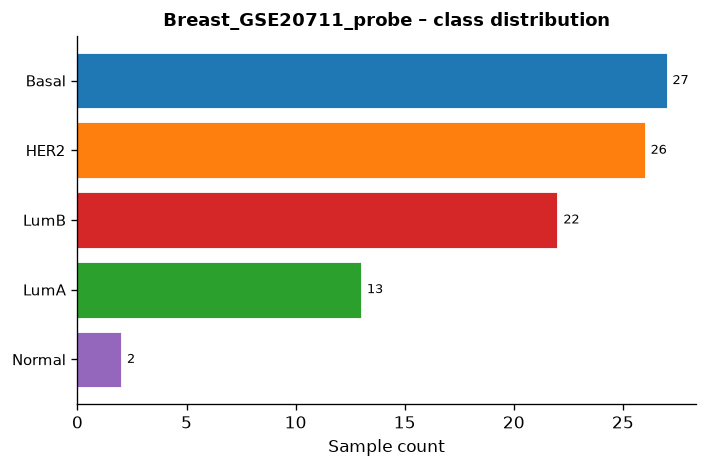

In [5]:
if target_path is not None:
    plot_class_distribution(data, title=f"{target_name} – class distribution");

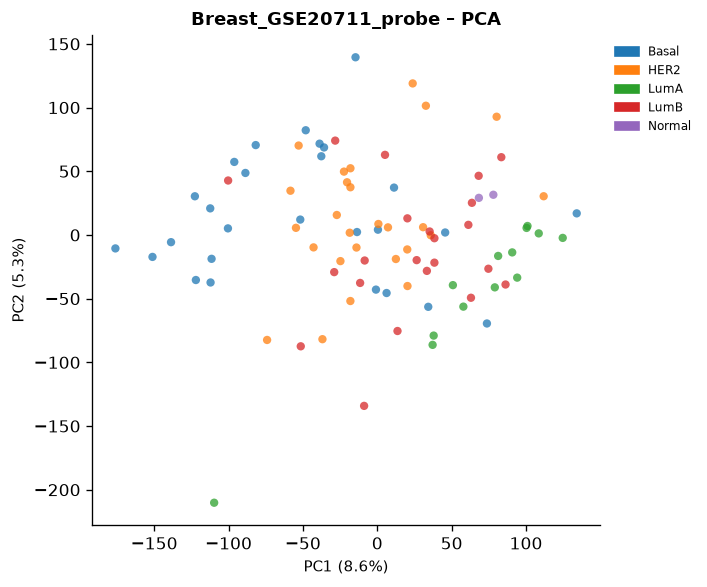

In [6]:
if target_path is not None:
    plot_pca(data, title=f"{target_name} – PCA");

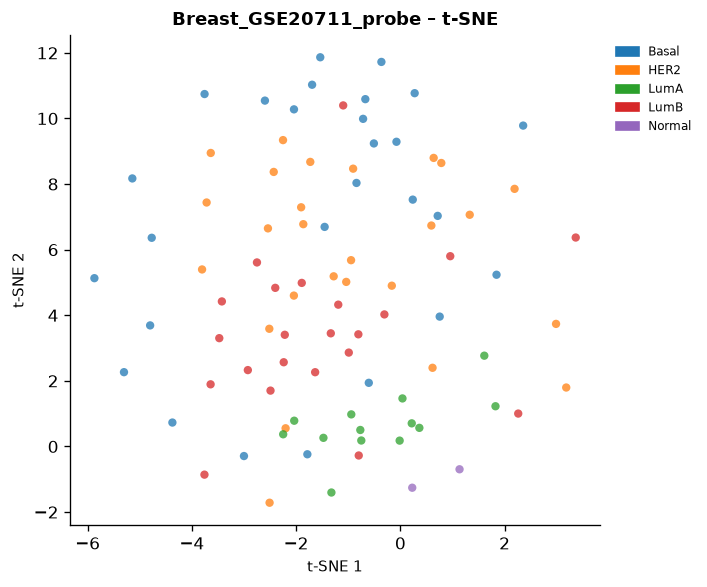

In [7]:
if target_path is not None:
    plot_tsne(data, title=f"{target_name} – t-SNE");

C:\Users\Bao Nguyen\LearningWithClaude\LV_code\src\visualize\plots.py:551: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


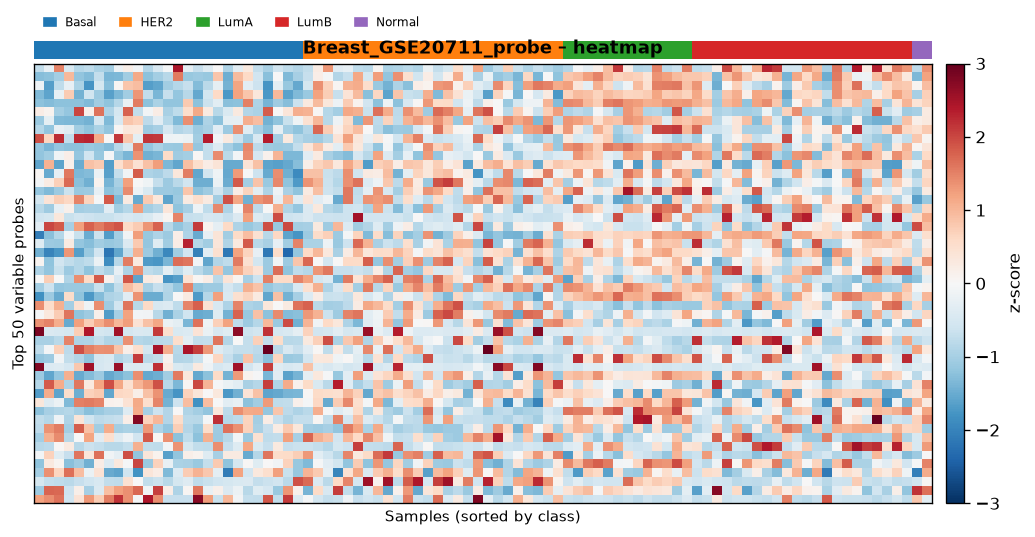

In [8]:
if target_path is not None:
    plot_expression_heatmap(data, title=f"{target_name} – heatmap", top_n=50);

## 5. Full overview — all datasets

Generates one 4-panel figure per dataset and saves two copies:

| Folder | Description |
|--------|-------------|
| `outputs/visualizations/original/` | Class names only (e.g. *basal*) |
| `outputs/visualizations/labeled/` | Class name + integer ID (e.g. *basal (0)*) |

Plotting Breast_GSE20711_probe ...
  [original] -> outputs\visualizations\original\Breast_GSE20711_probe.png
  [labeled] -> outputs\visualizations\labeled\Breast_GSE20711_probe.png


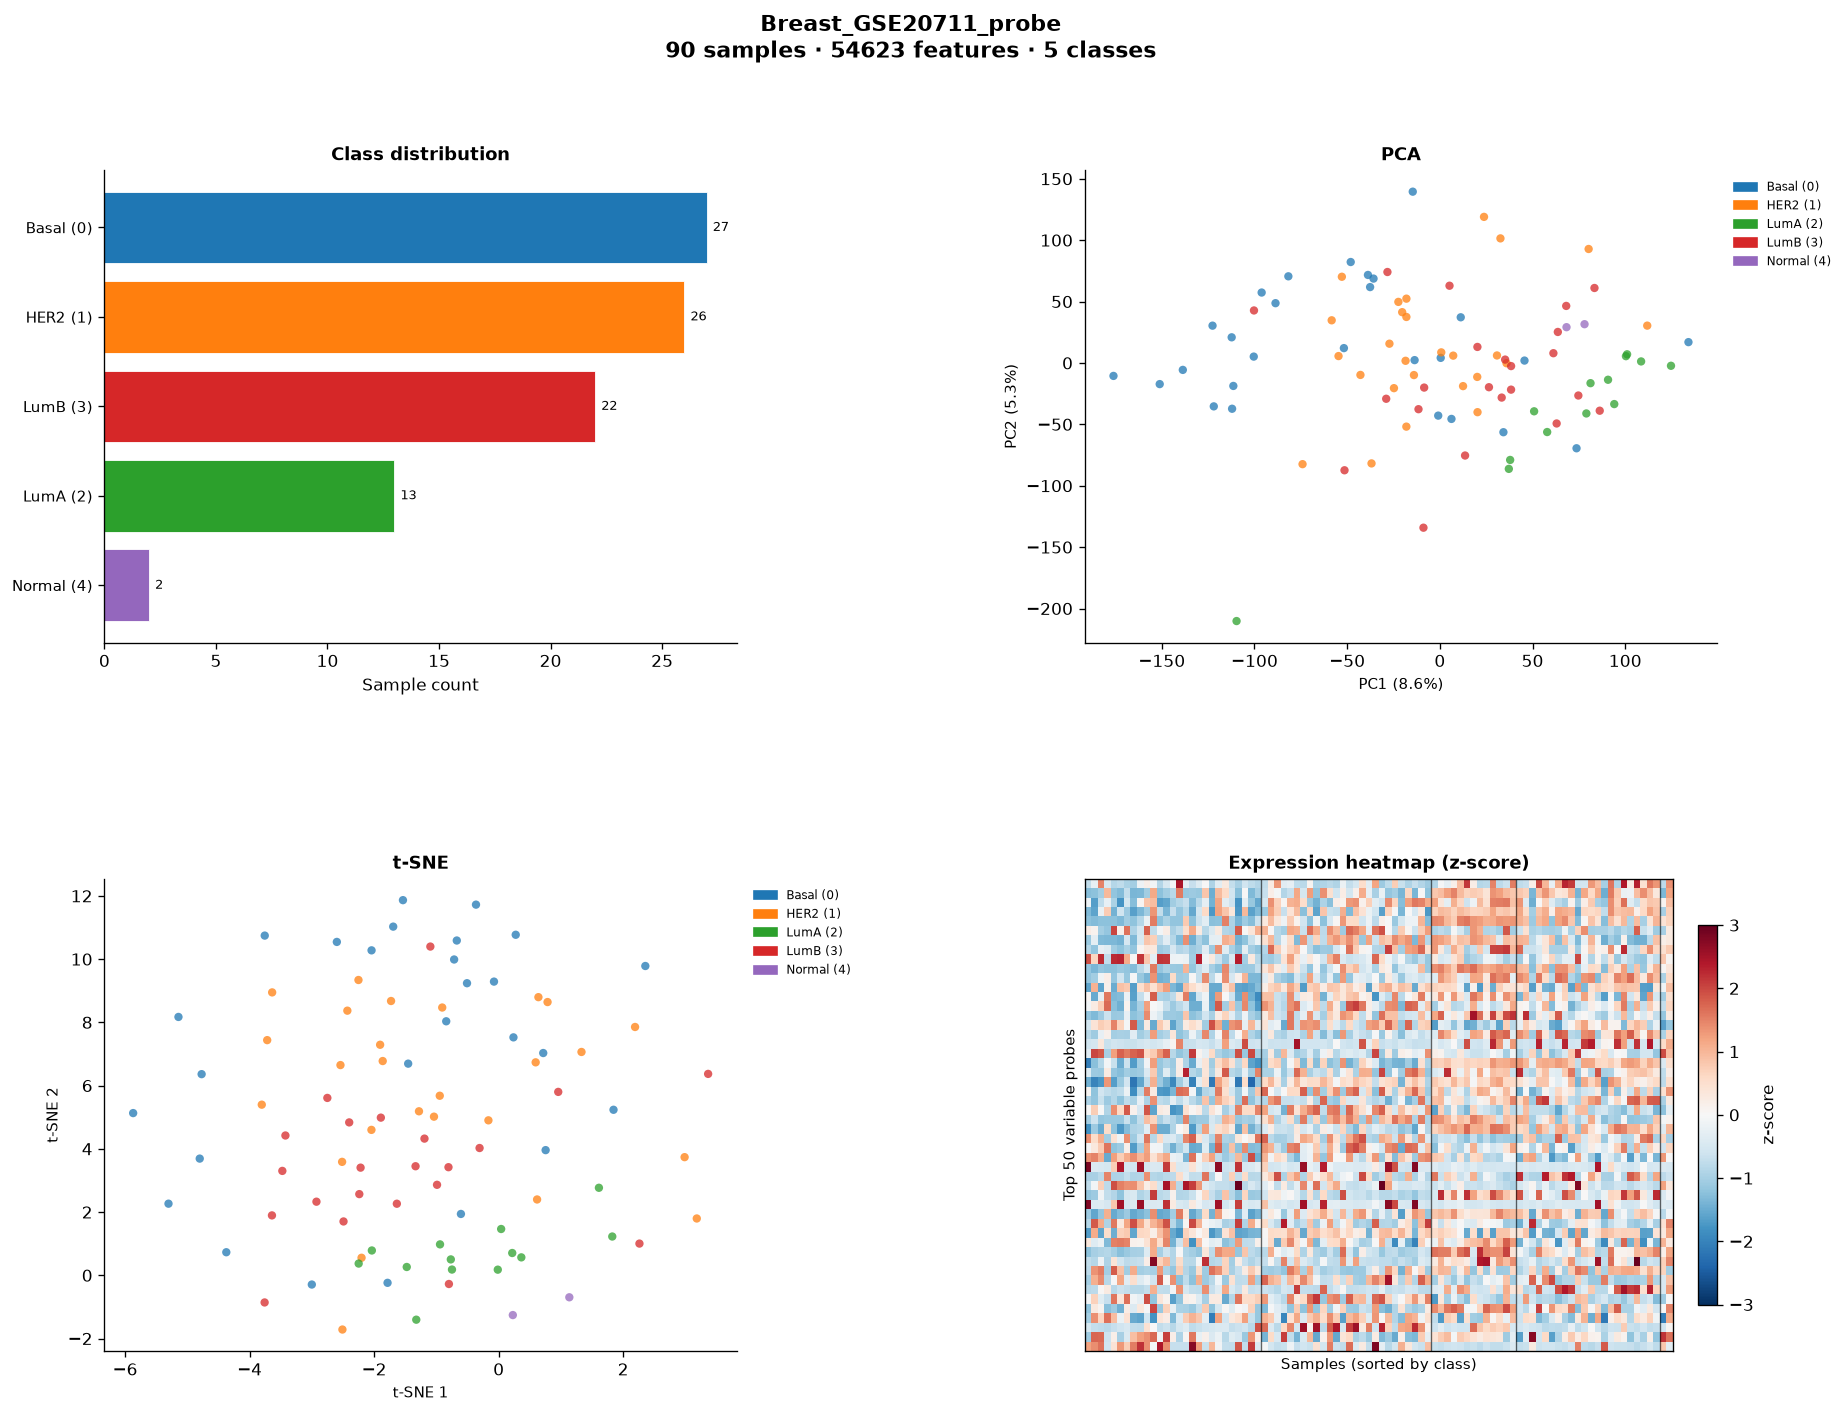

Plotting Mesothelioma_GSE29354_probe ...
  [original] -> outputs\visualizations\original\Mesothelioma_GSE29354_probe.png
  [labeled] -> outputs\visualizations\labeled\Mesothelioma_GSE29354_probe.png


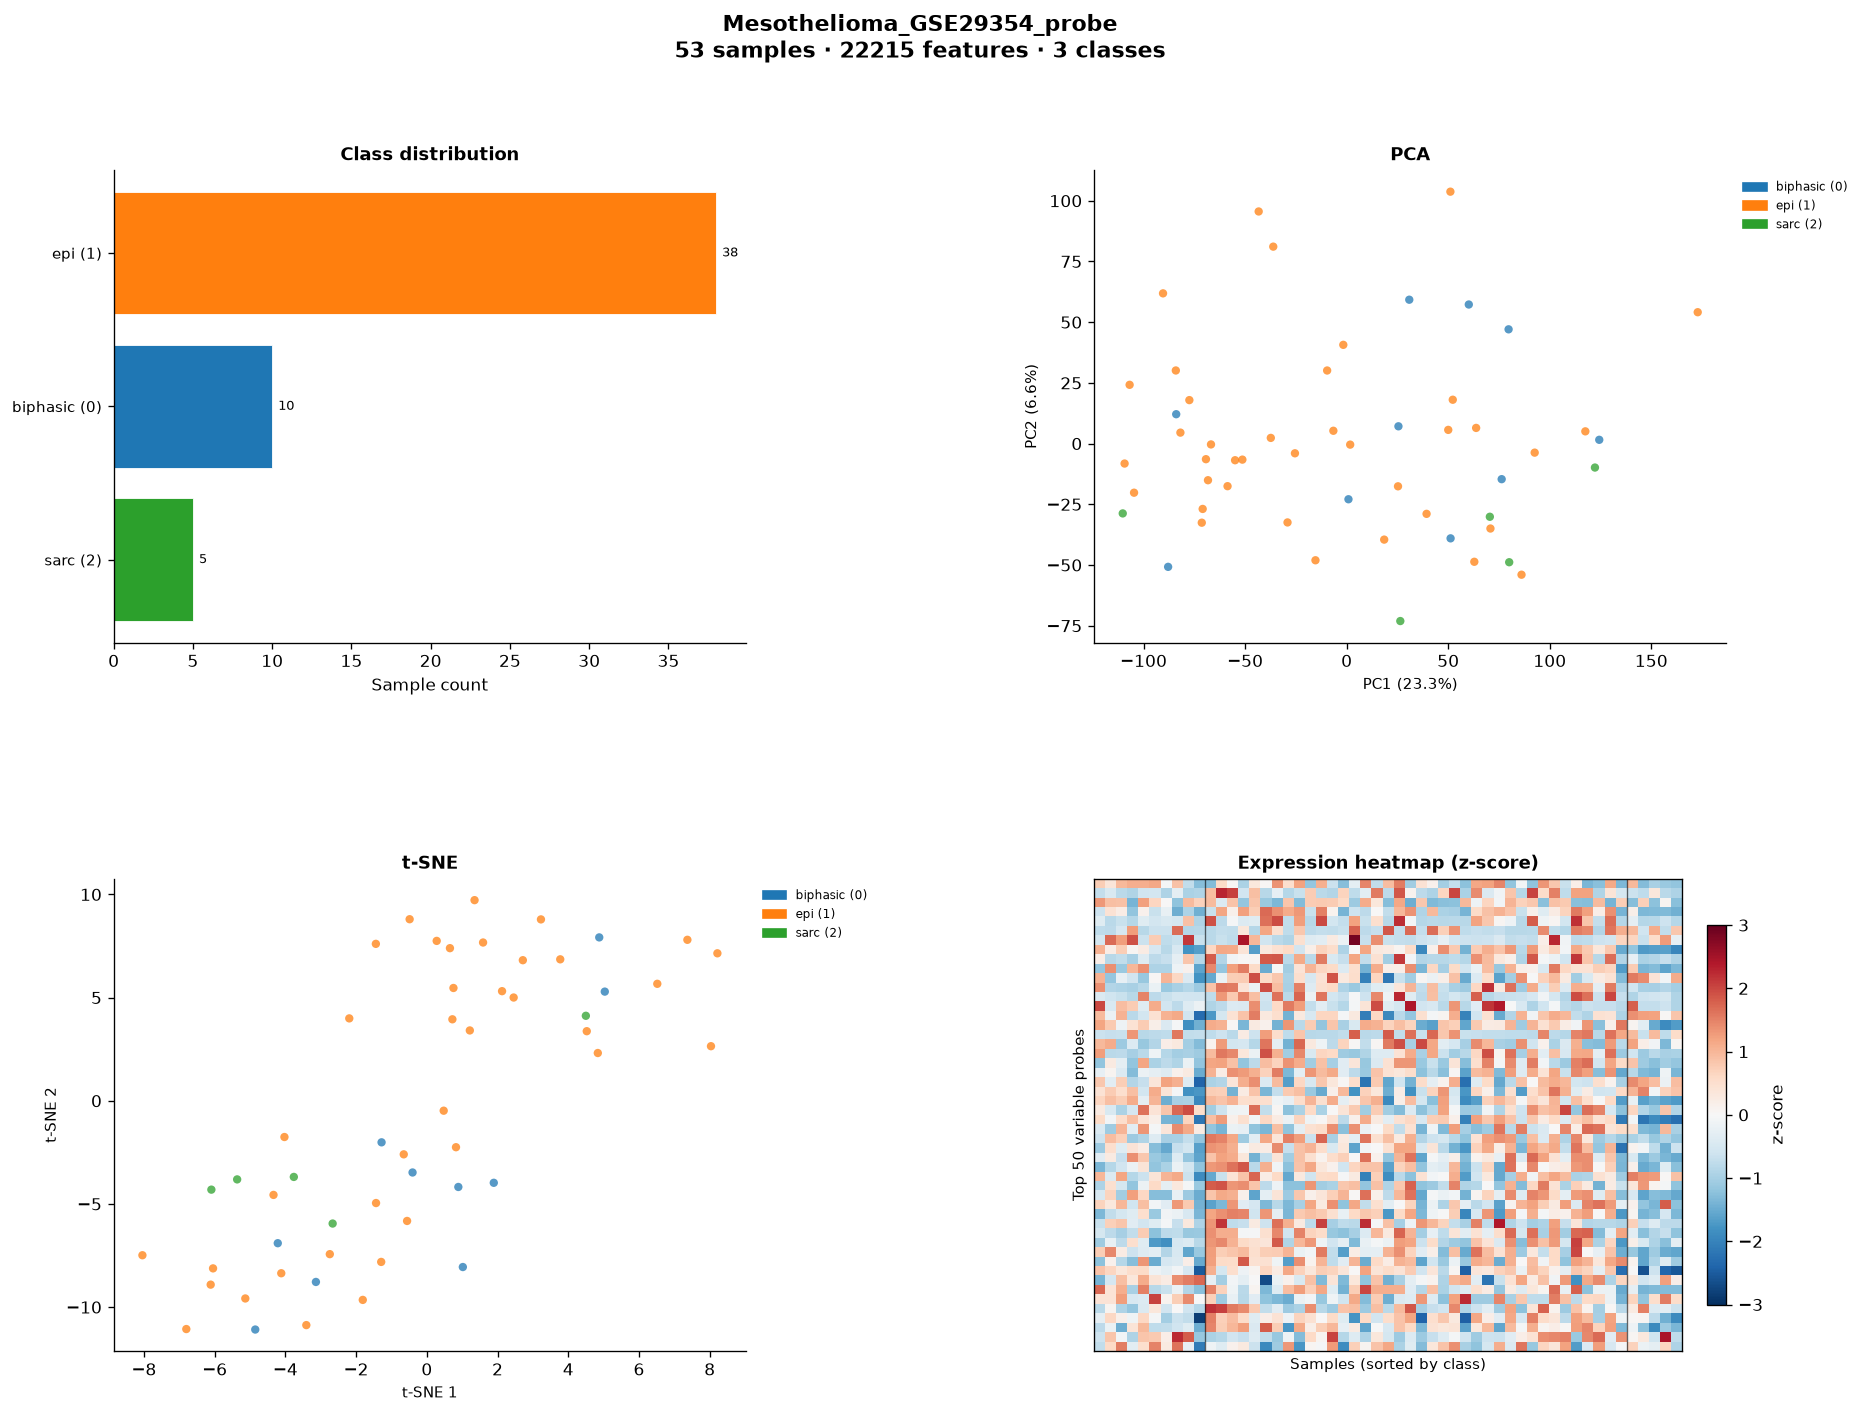

Plotting Kidney_GSE36895_probe ...
  [original] -> outputs\visualizations\original\Kidney_GSE36895_probe.png
  [labeled] -> outputs\visualizations\labeled\Kidney_GSE36895_probe.png


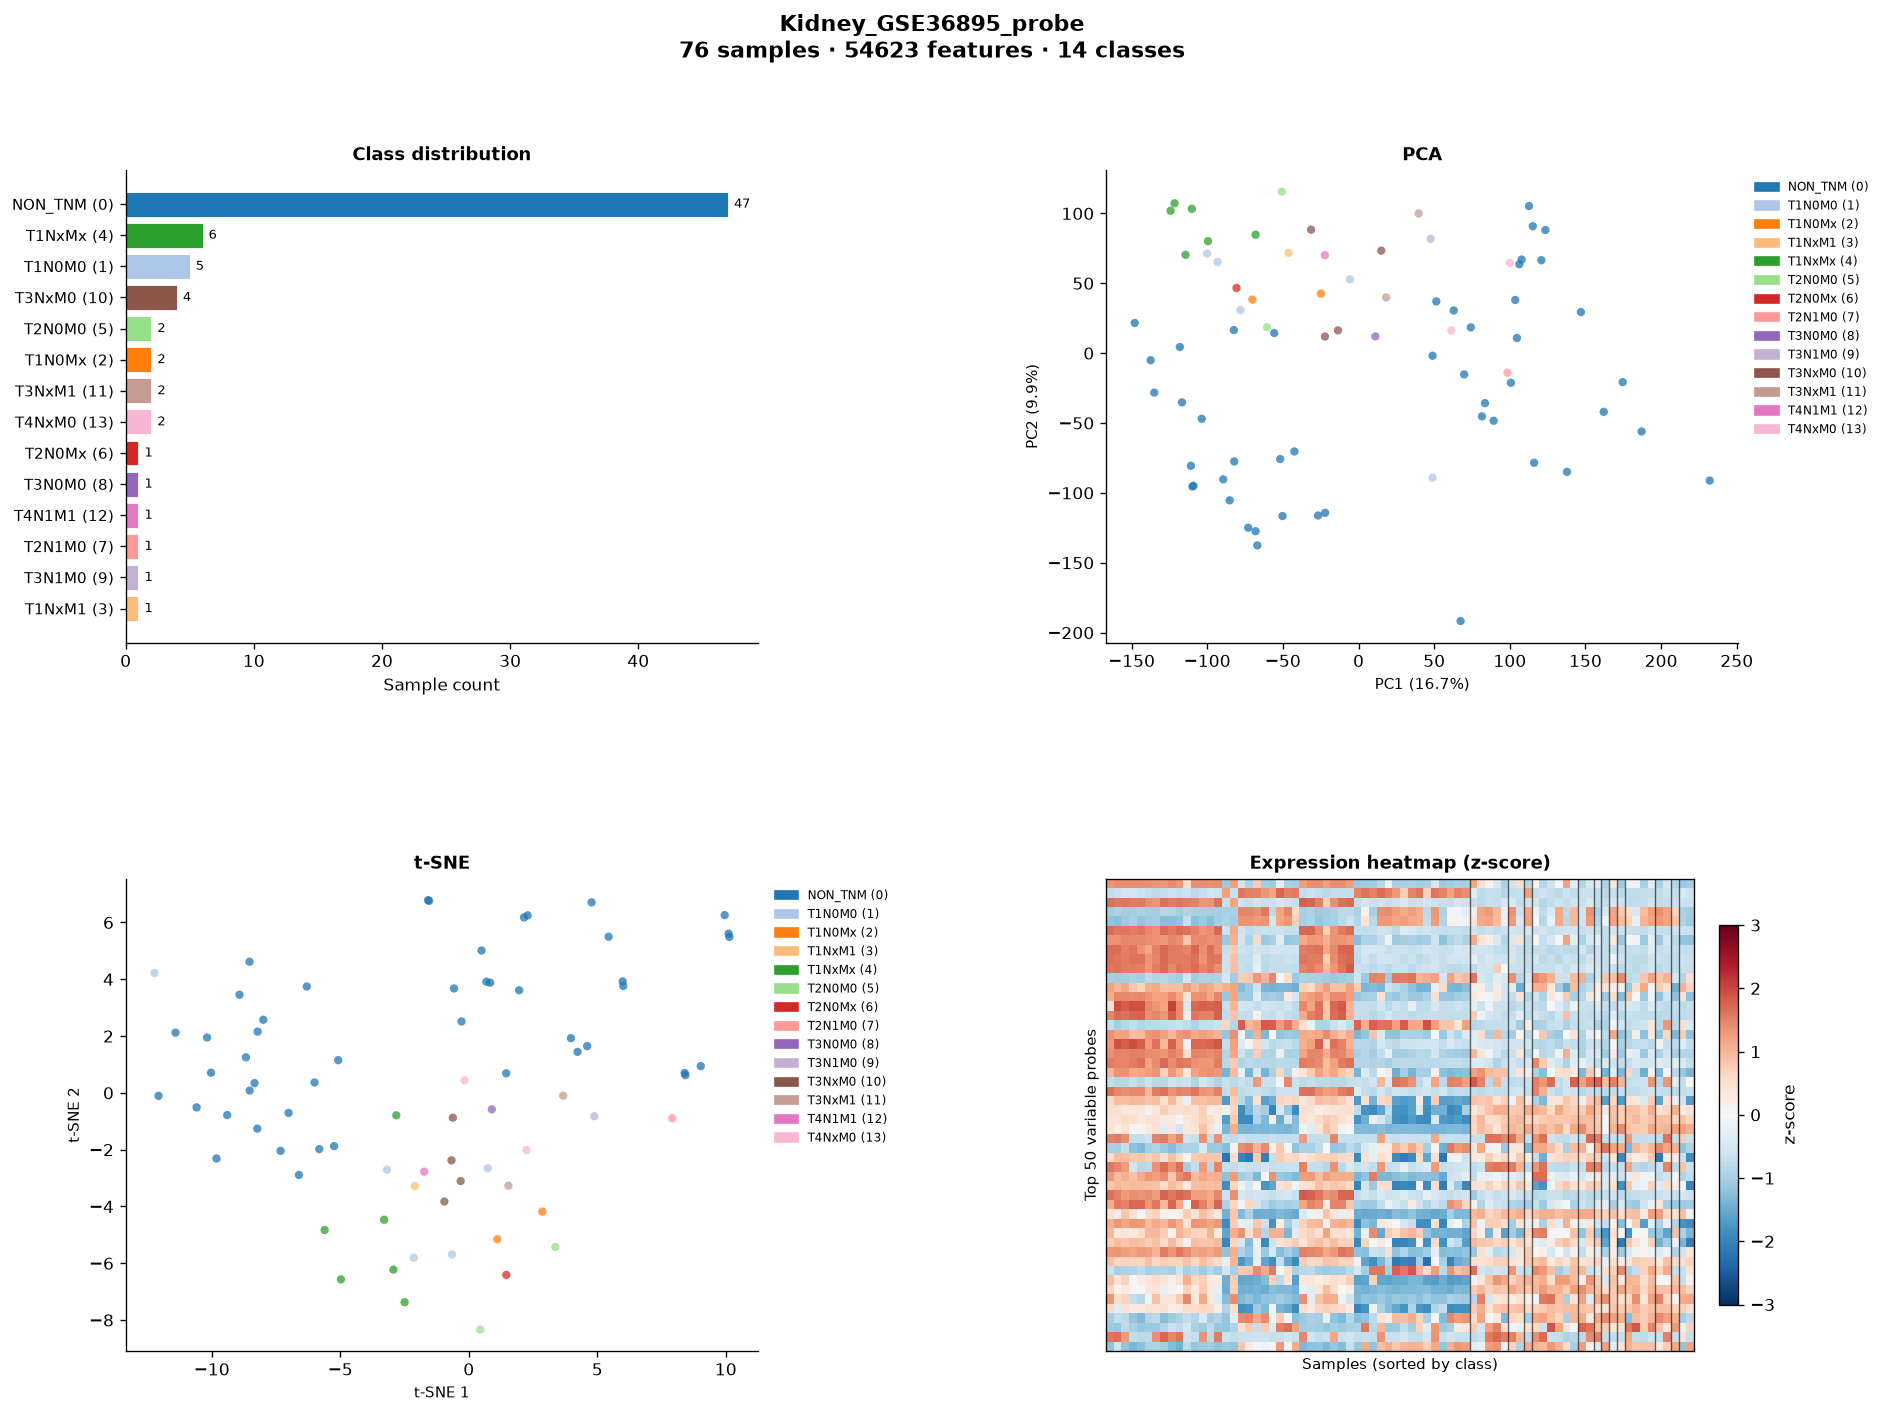

Plotting Colon_GSE68468_probe ...
  [original] -> outputs\visualizations\original\Colon_GSE68468_probe.png
  [labeled] -> outputs\visualizations\labeled\Colon_GSE68468_probe.png


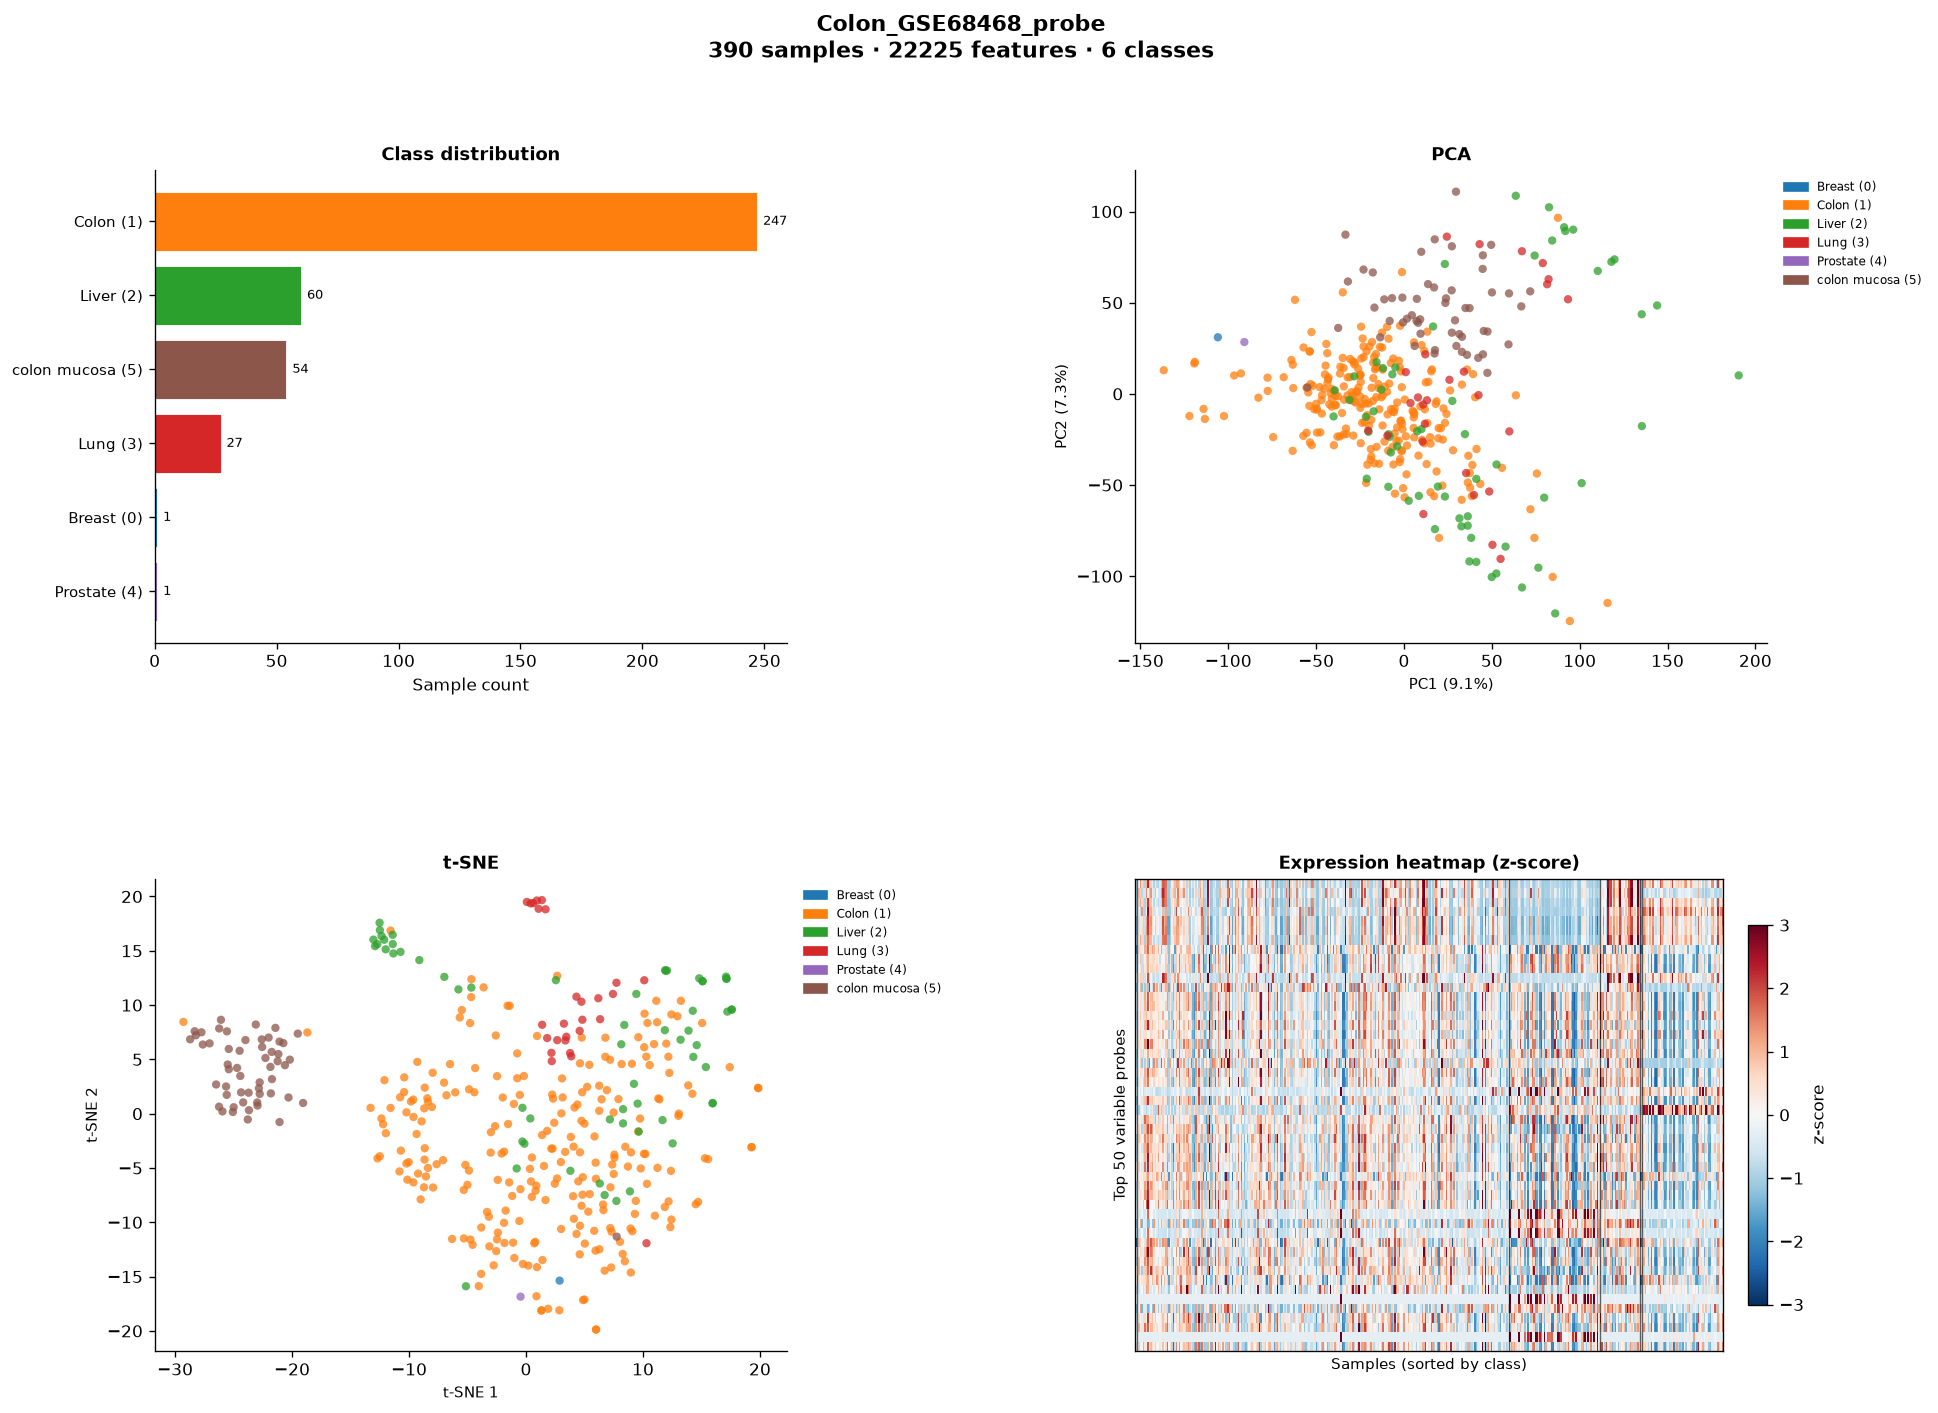

Plotting MultiCancer_GSE68606_probe ...
  [original] -> outputs\visualizations\original\MultiCancer_GSE68606_probe.png
  [labeled] -> outputs\visualizations\labeled\MultiCancer_GSE68606_probe.png


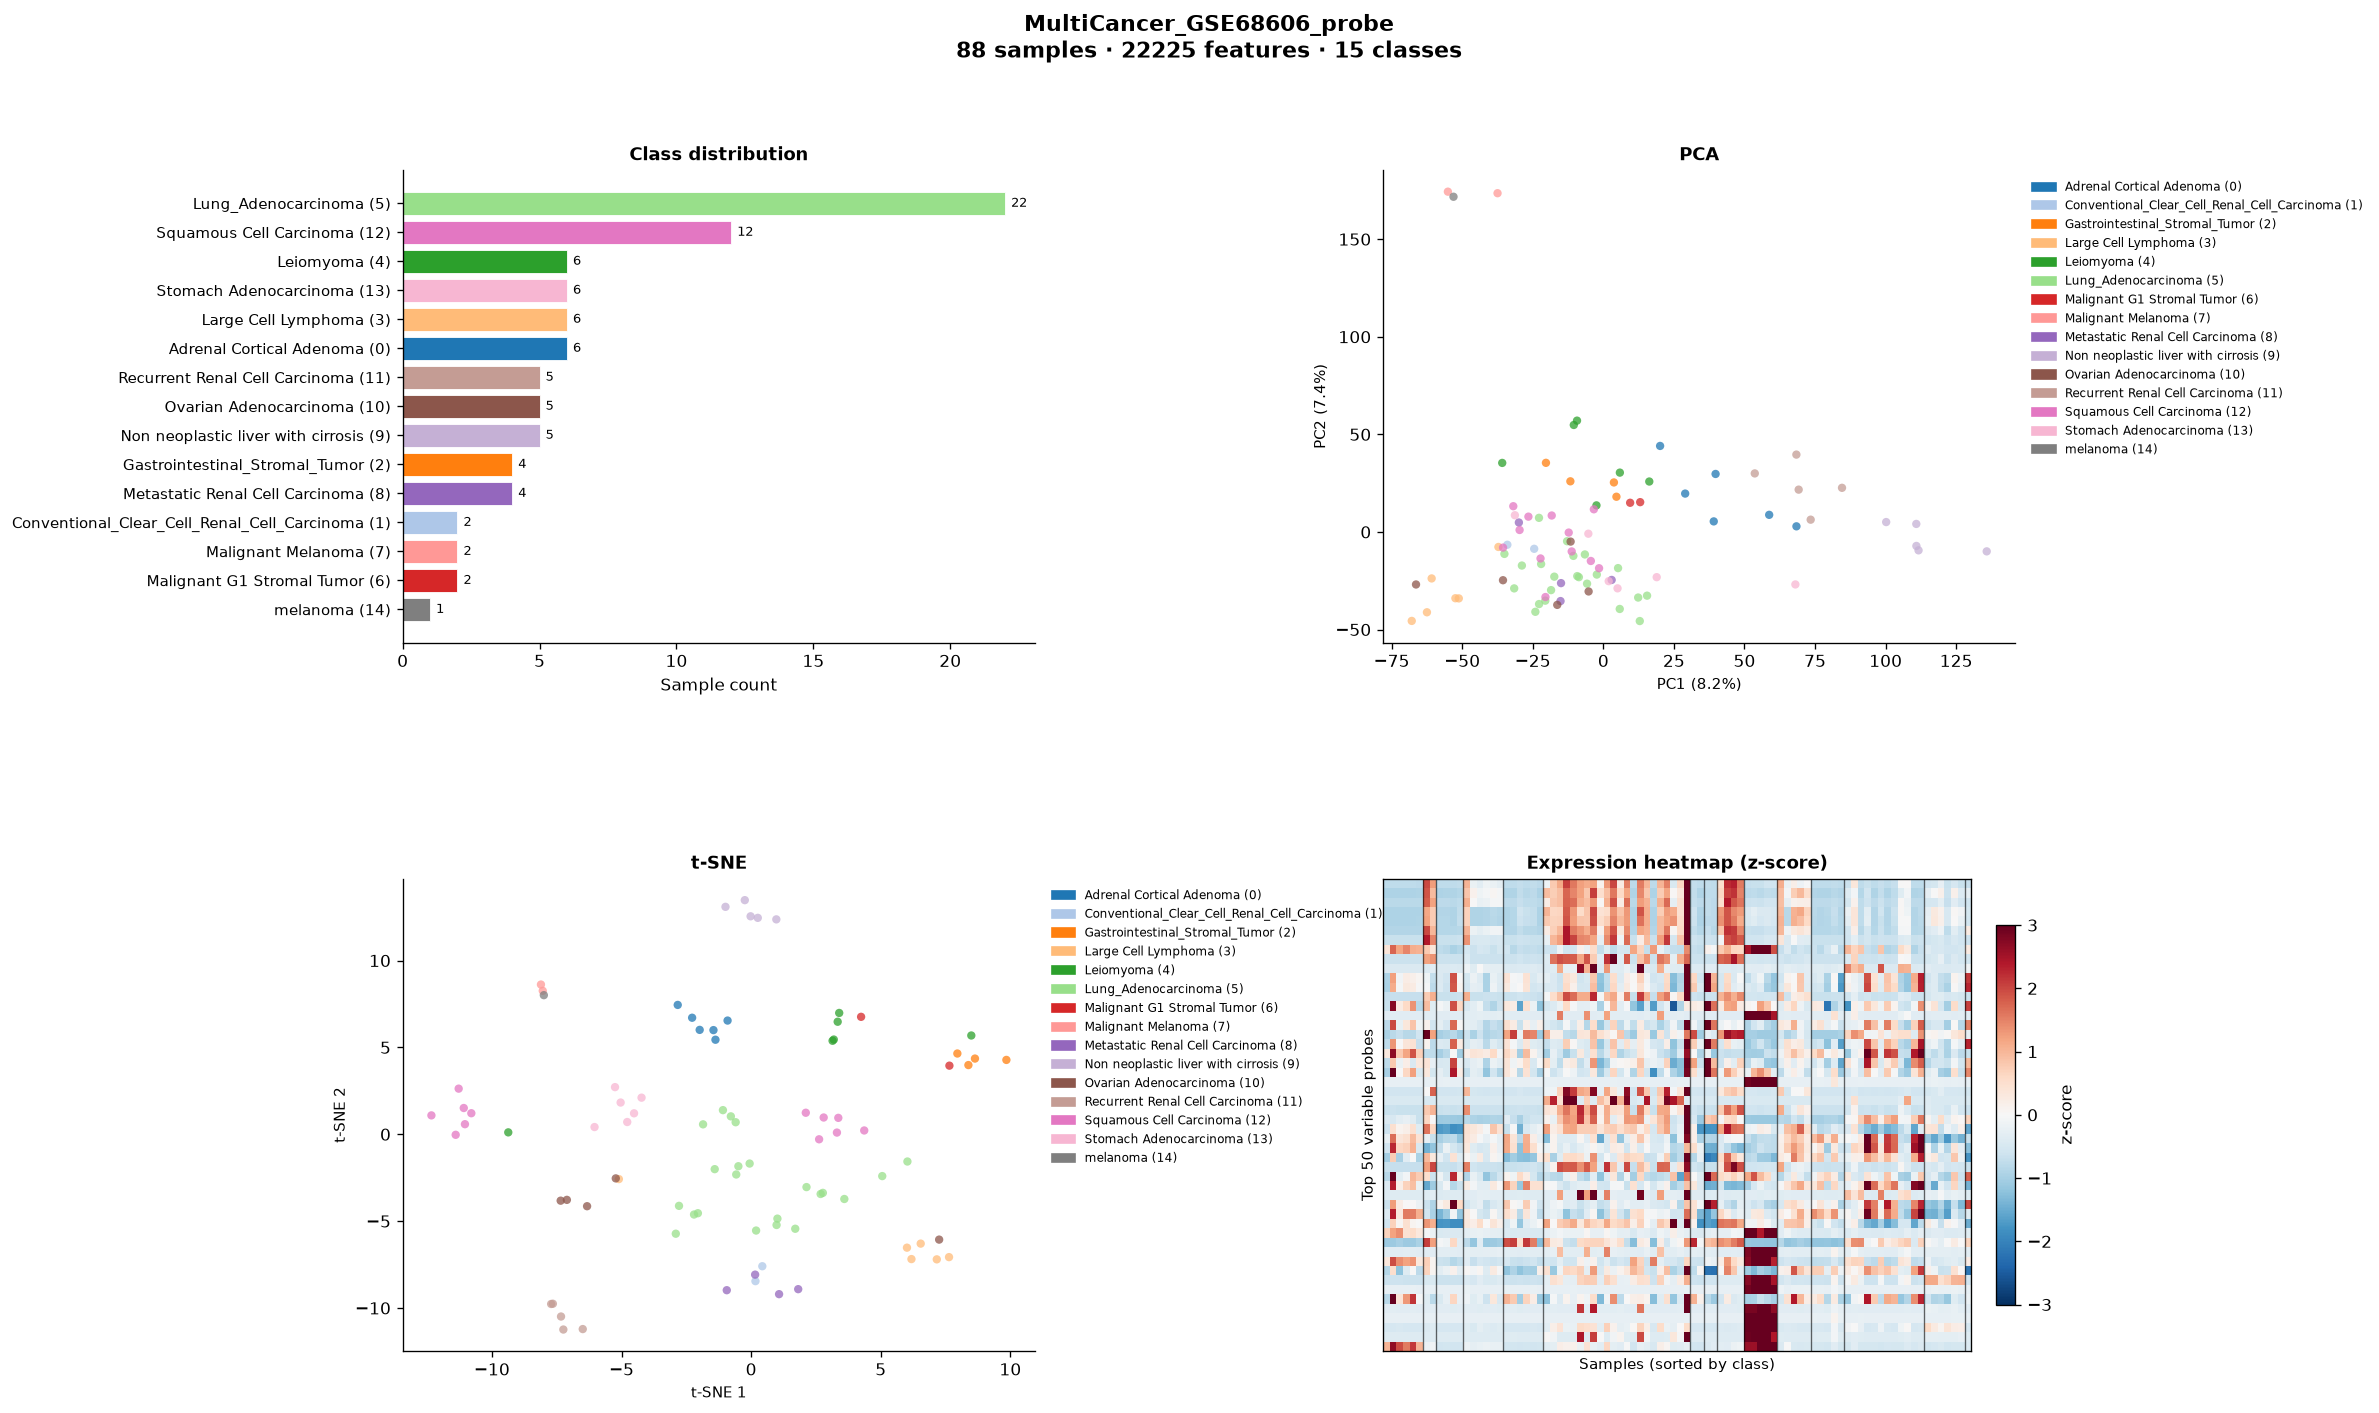

Plotting Ovary_GSE6008_probe ...
  [original] -> outputs\visualizations\original\Ovary_GSE6008_probe.png
  [labeled] -> outputs\visualizations\labeled\Ovary_GSE6008_probe.png


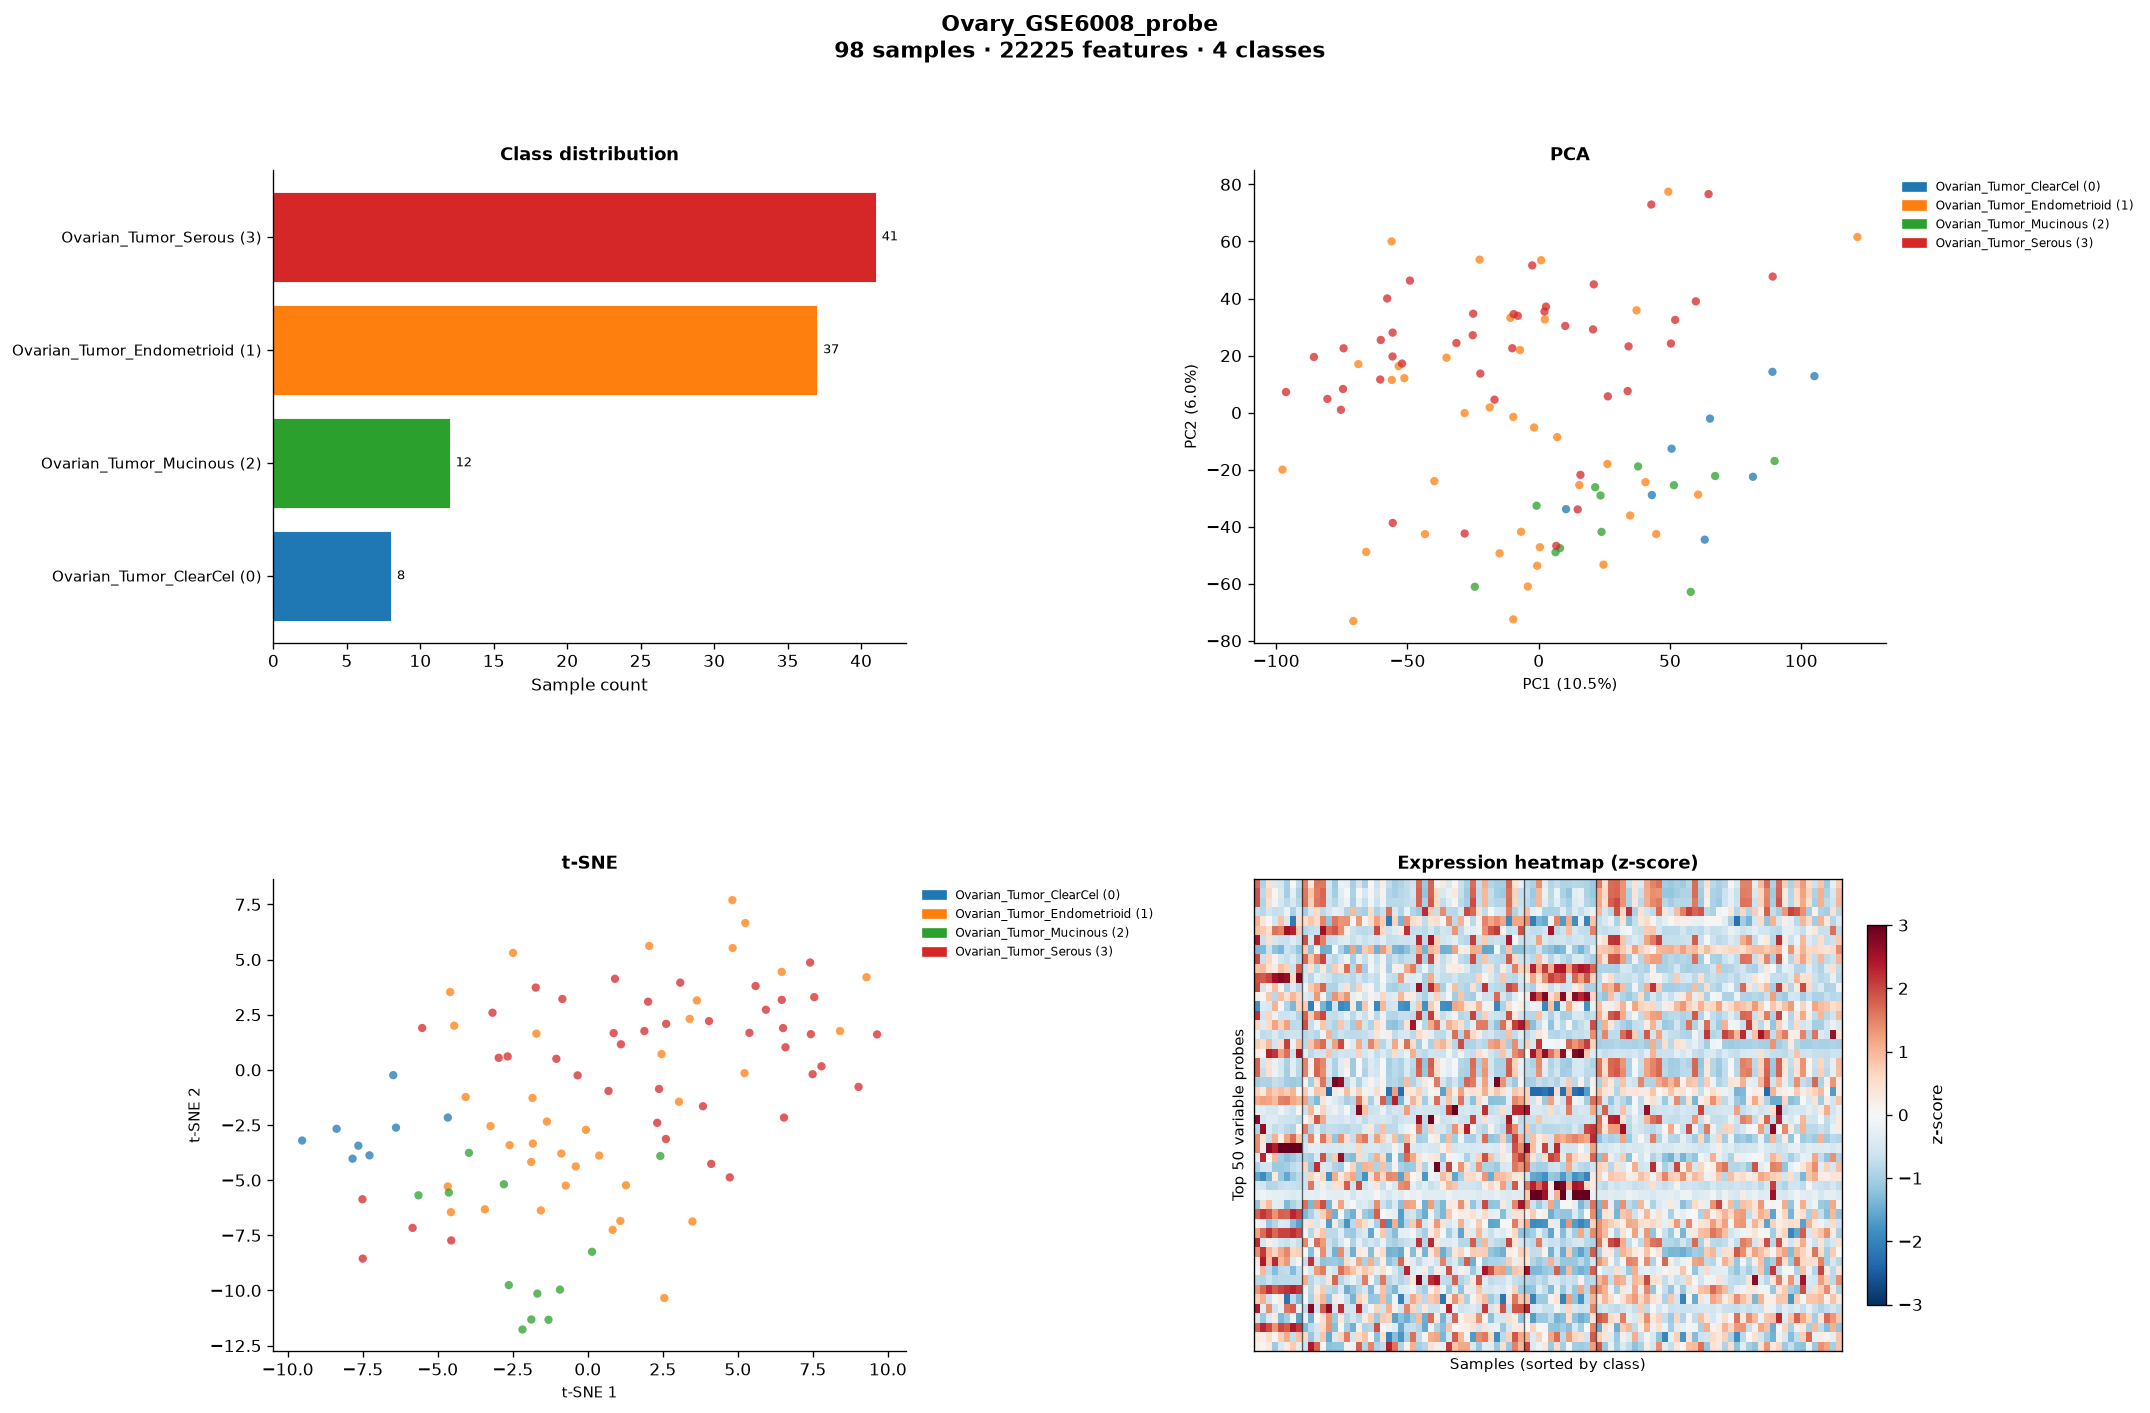

Plotting Brain_GSE15824_probe ...
  [original] -> outputs\visualizations\original\Brain_GSE15824_probe.png
  [labeled] -> outputs\visualizations\labeled\Brain_GSE15824_probe.png


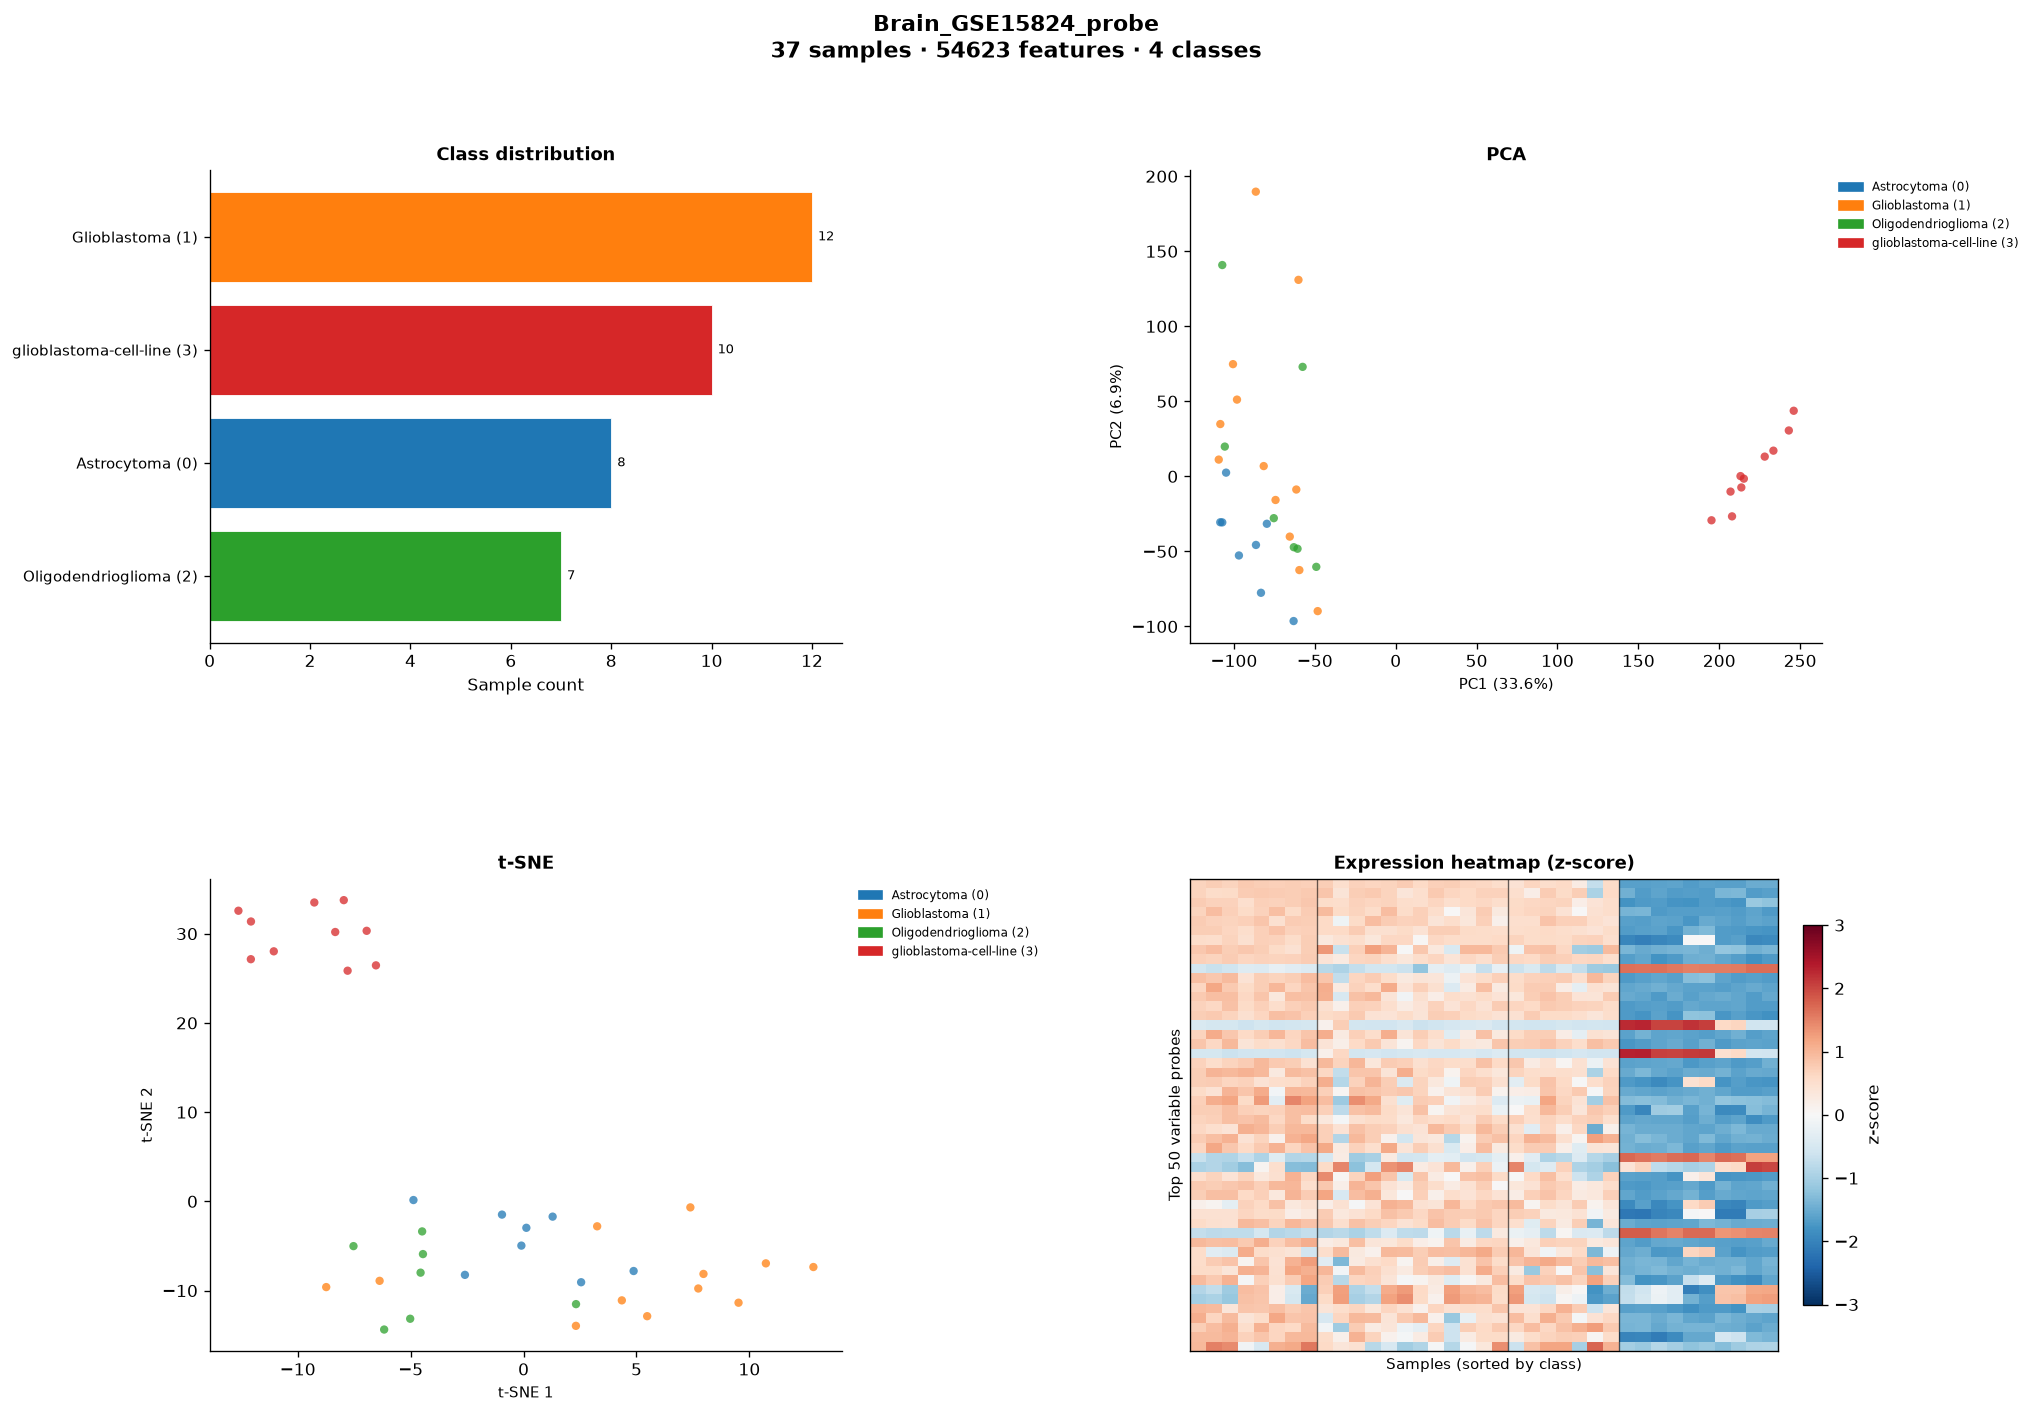

Plotting Breast_GSE26304_probe ...
  [original] -> outputs\visualizations\original\Breast_GSE26304_probe.png
  [labeled] -> outputs\visualizations\labeled\Breast_GSE26304_probe.png


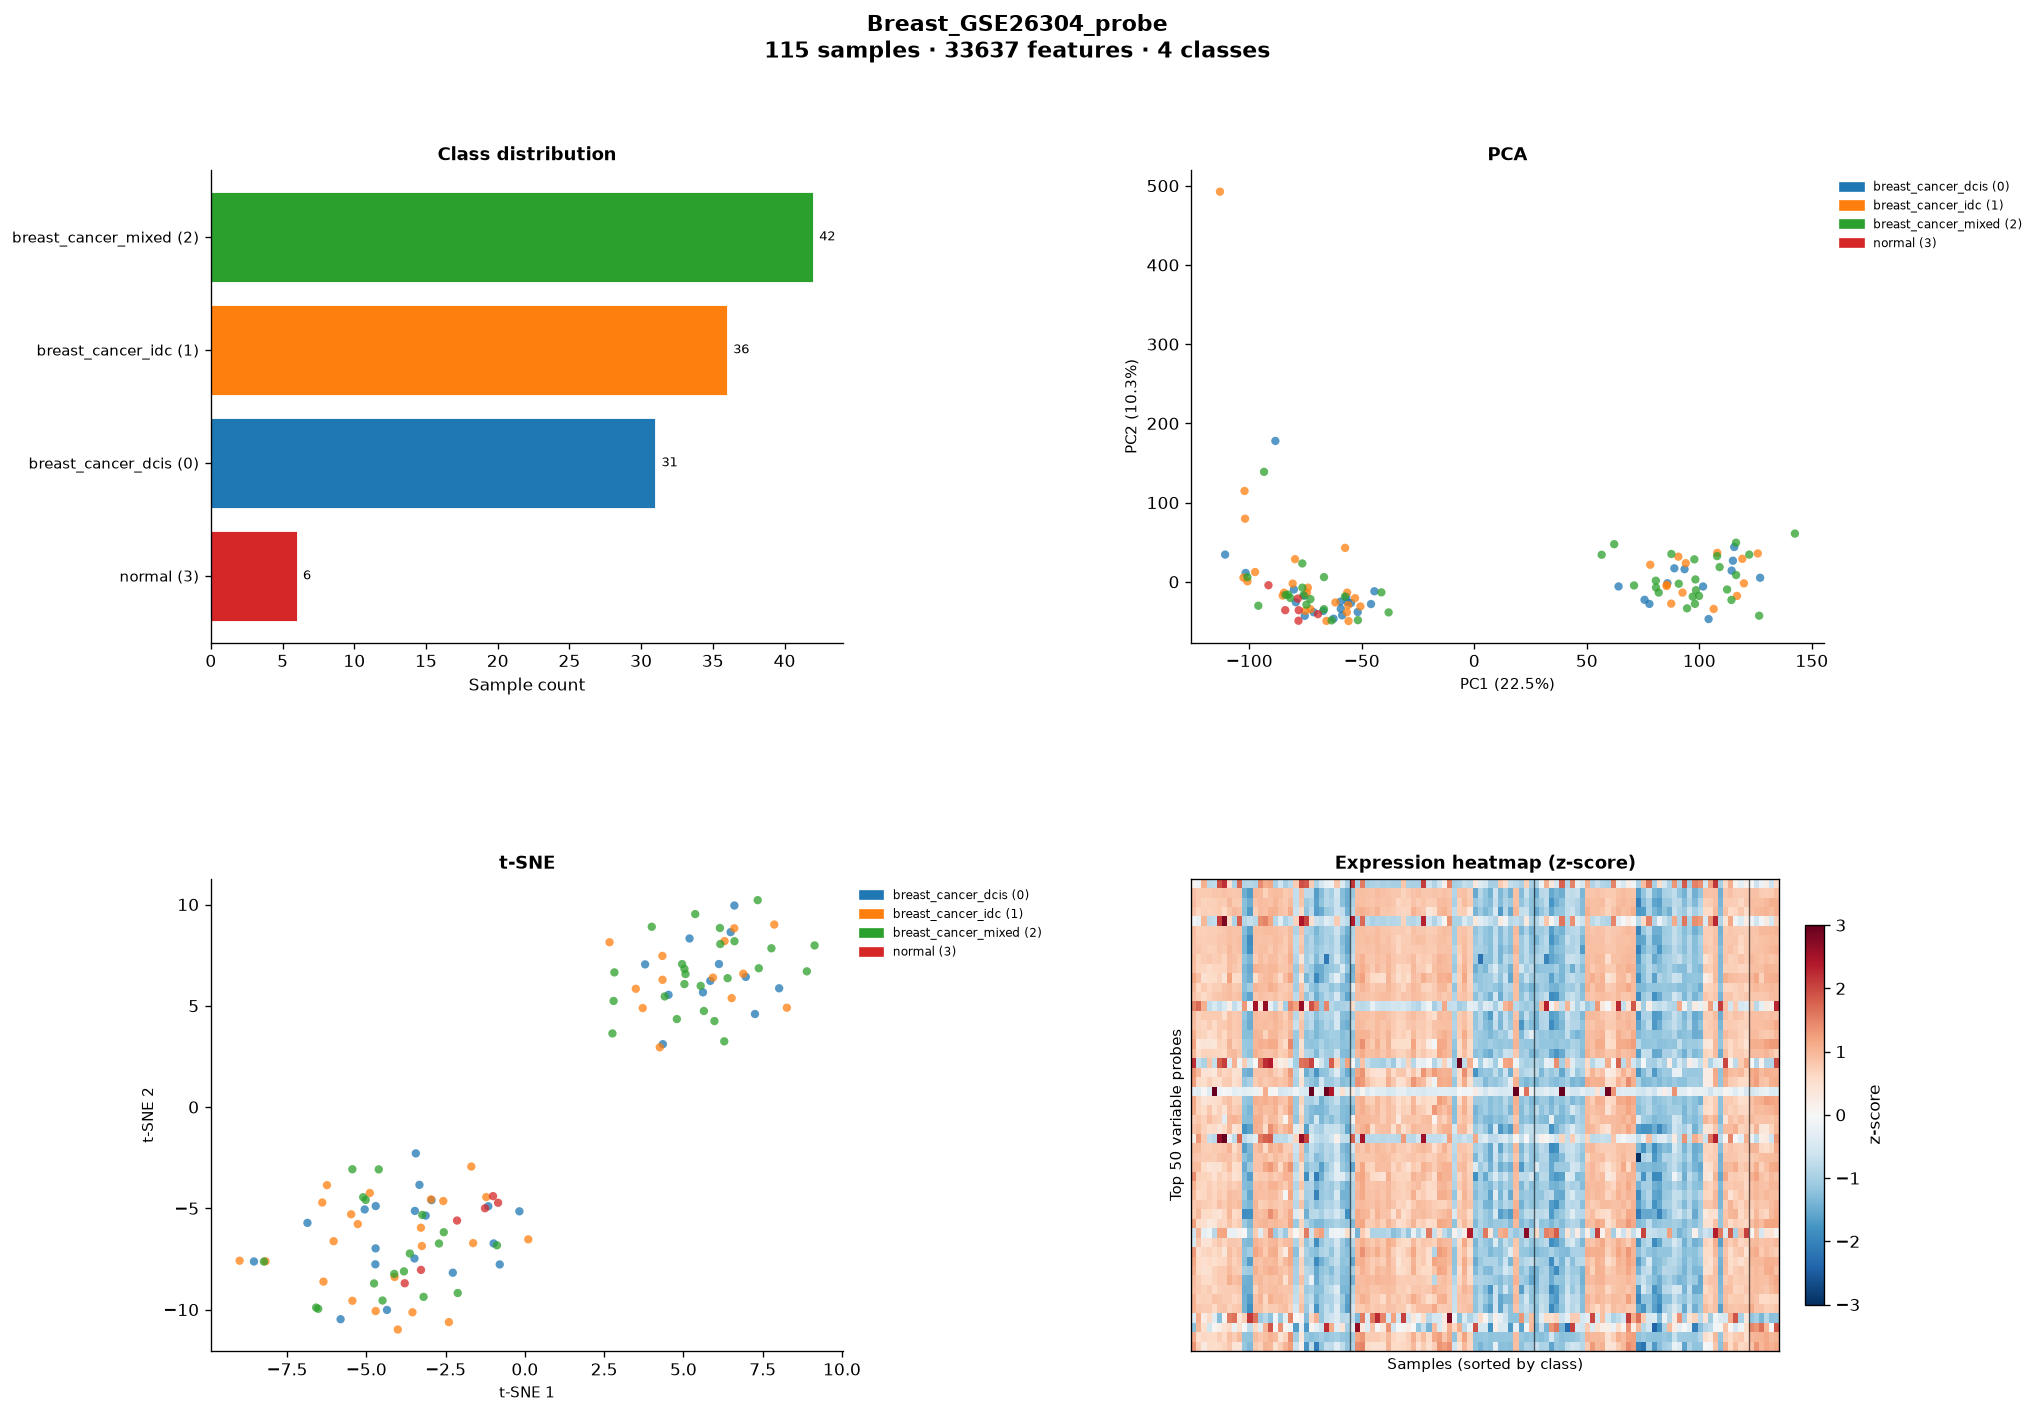

Plotting Leukemia_GSE28497_probe ...
  [original] -> outputs\visualizations\original\Leukemia_GSE28497_probe.png
  [labeled] -> outputs\visualizations\labeled\Leukemia_GSE28497_probe.png


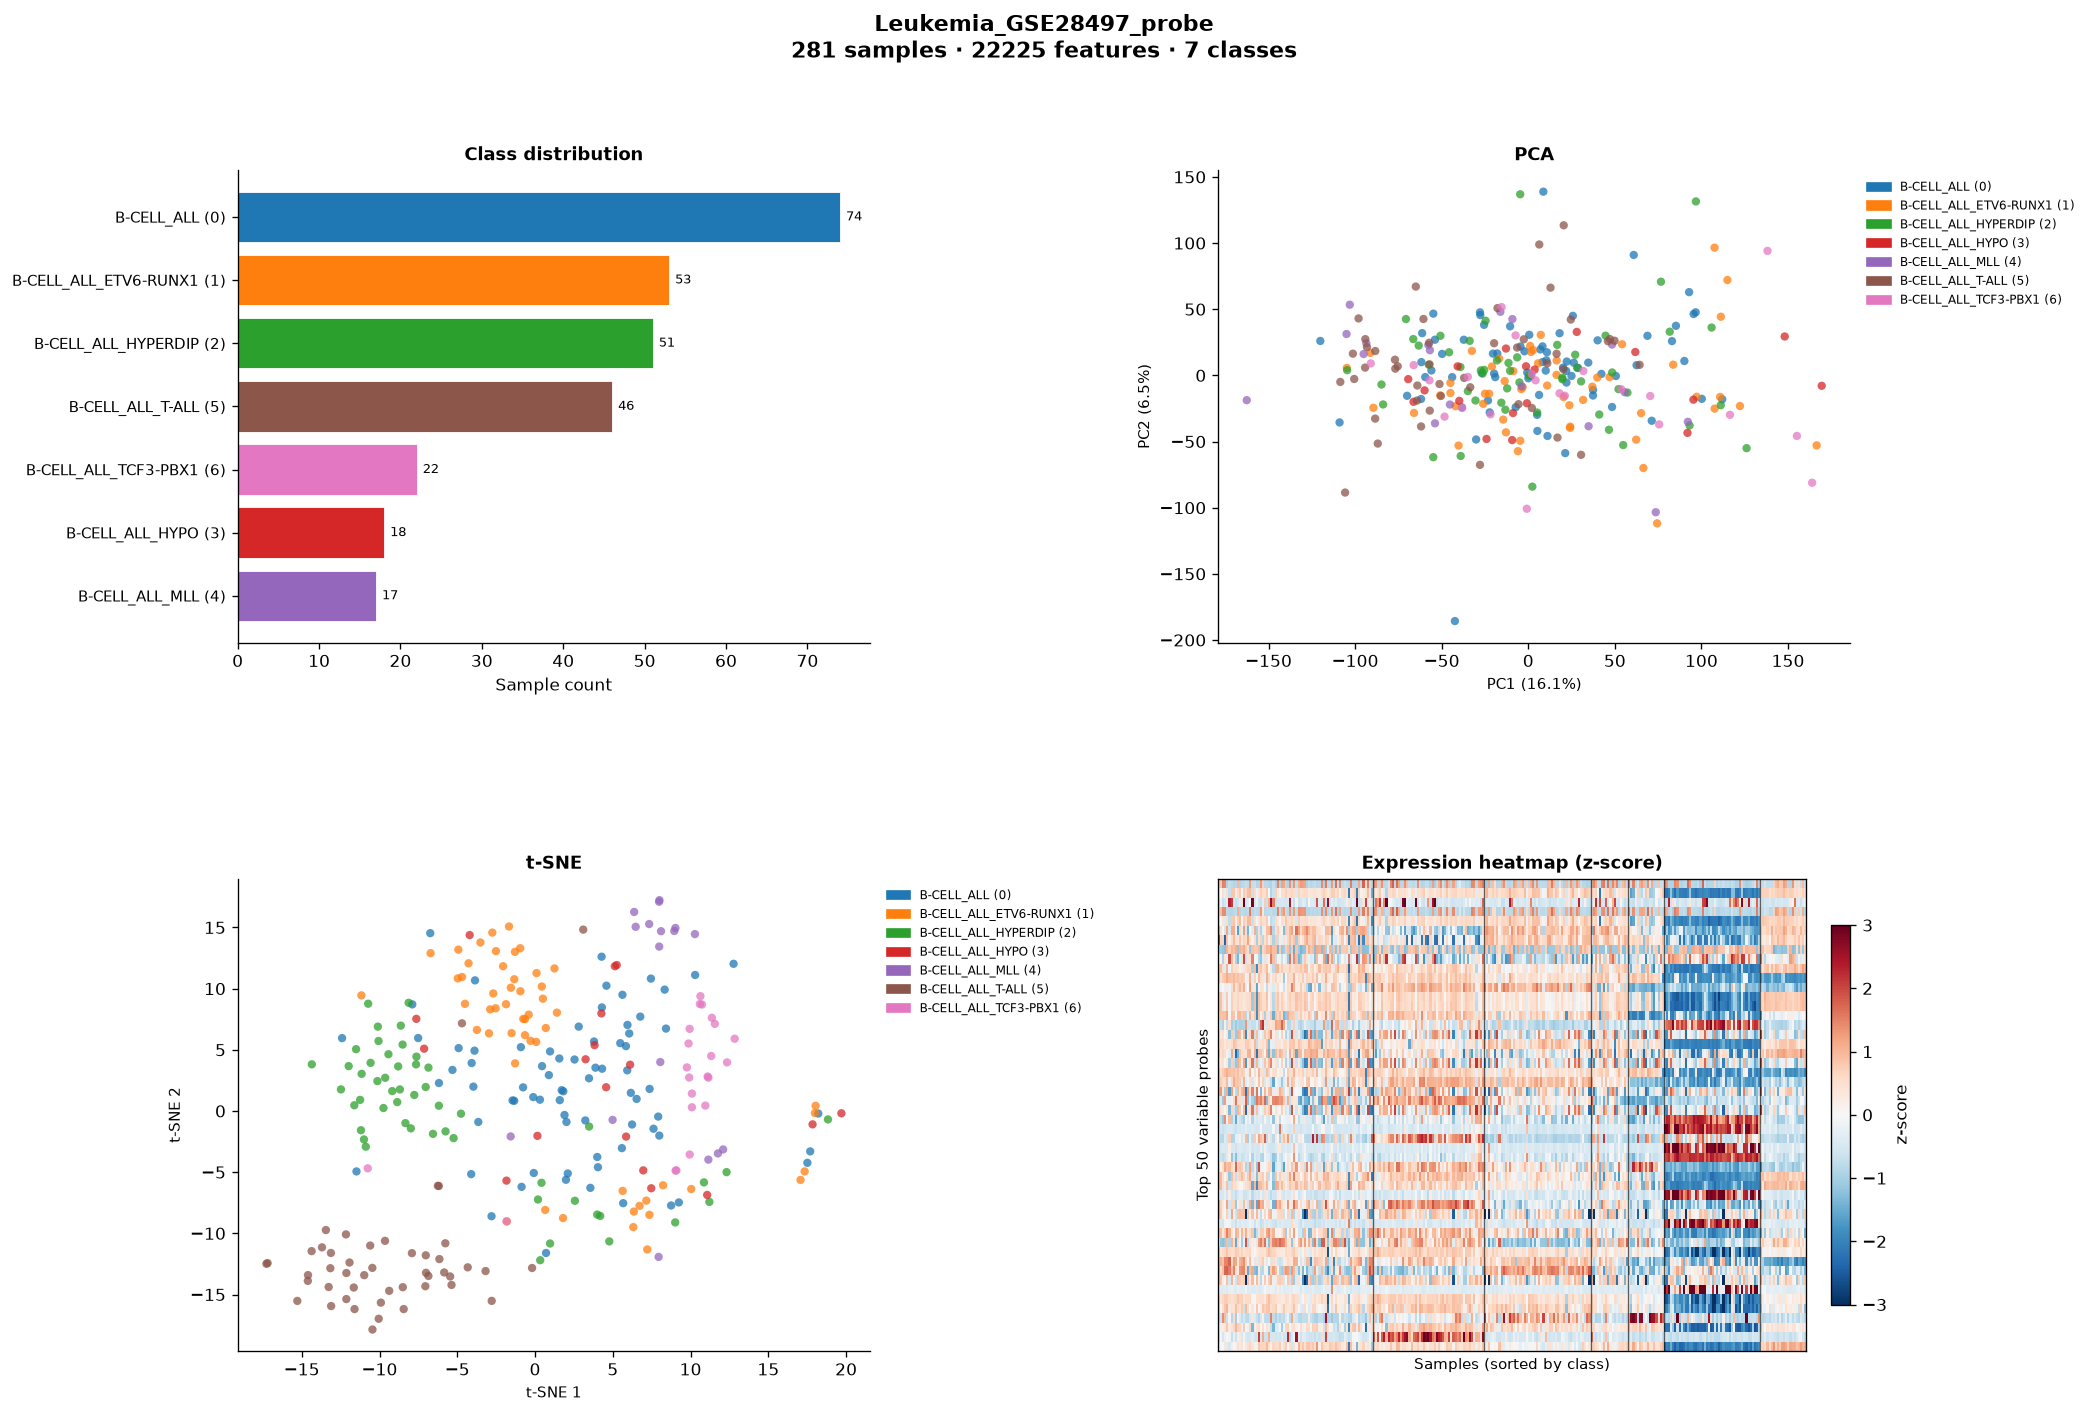

Plotting Colorectal_GSE41657_probe ...
  [original] -> outputs\visualizations\original\Colorectal_GSE41657_probe.png
  [labeled] -> outputs\visualizations\labeled\Colorectal_GSE41657_probe.png


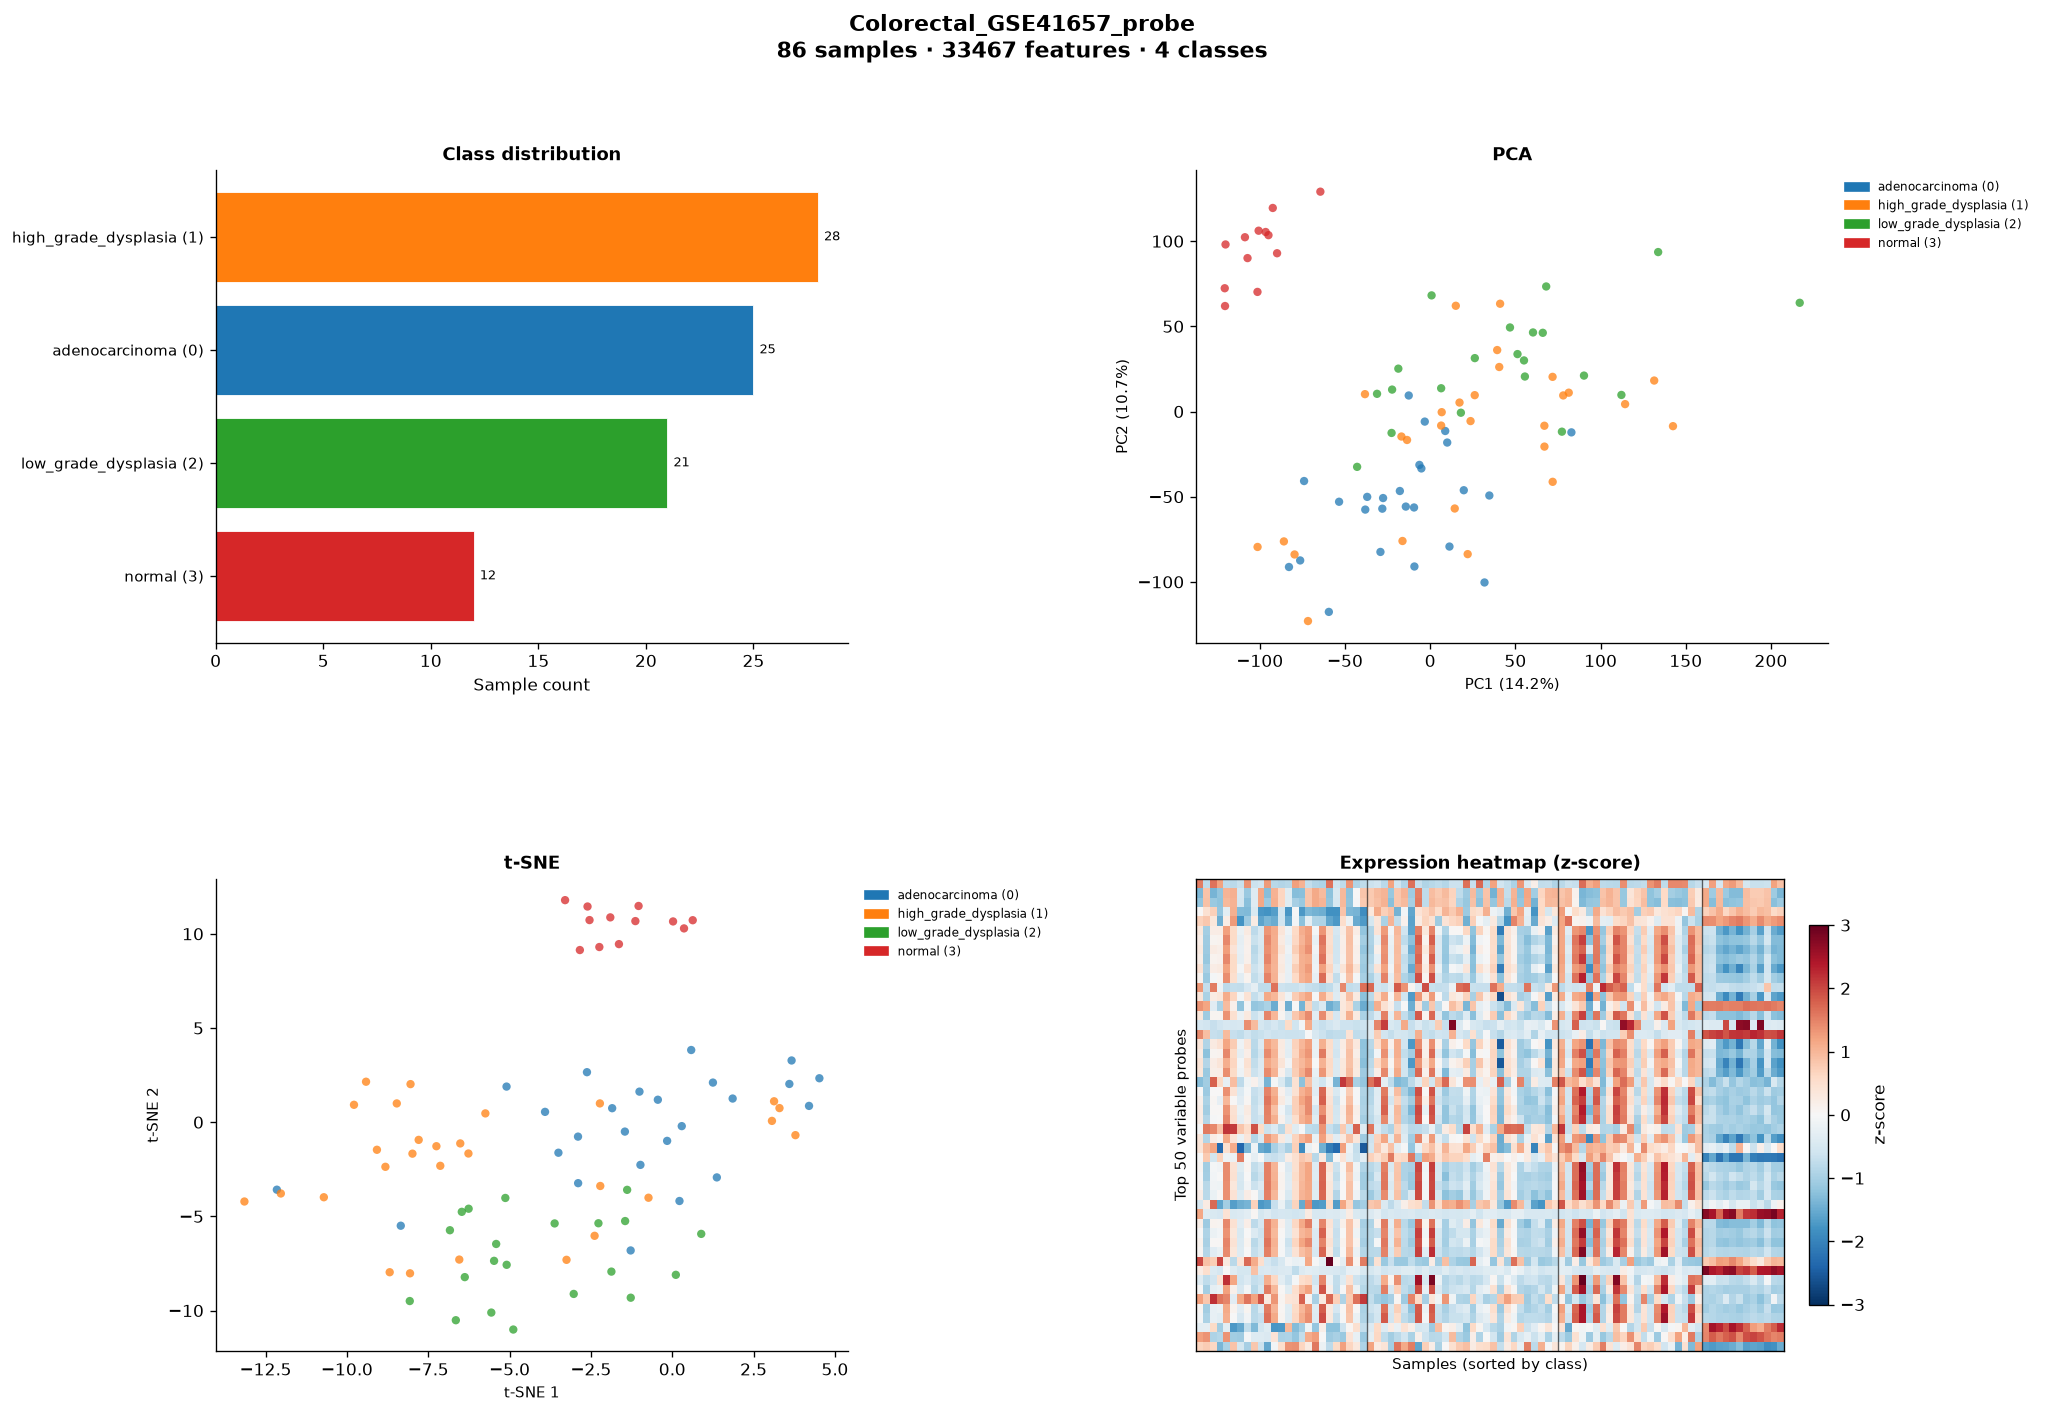

Plotting Breast_GSE45827_probe ...
  [original] -> outputs\visualizations\original\Breast_GSE45827_probe.png
  [labeled] -> outputs\visualizations\labeled\Breast_GSE45827_probe.png


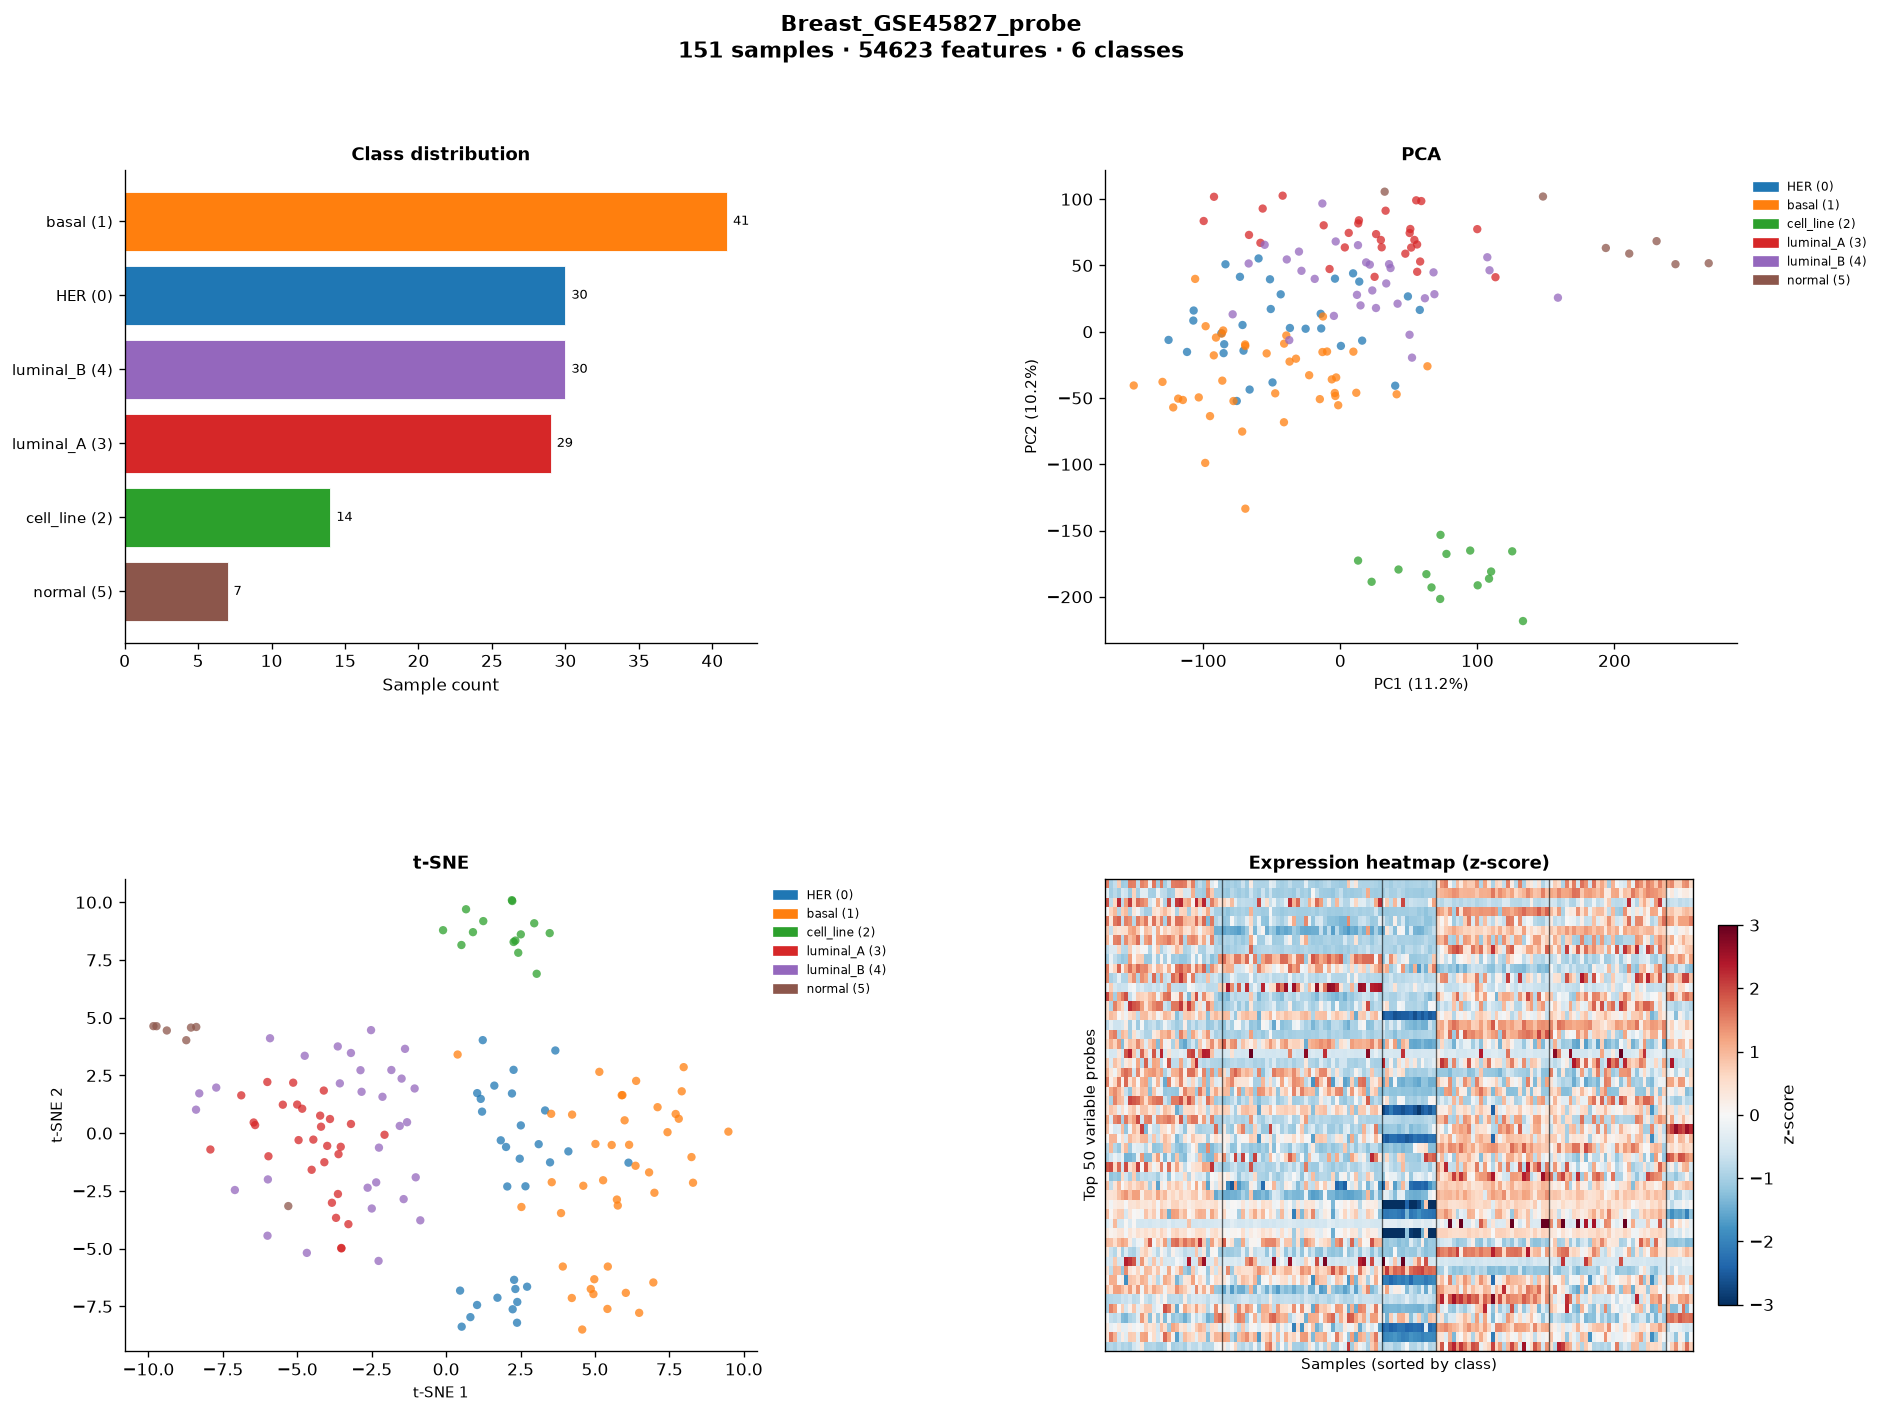

Plotting Brain_GSE50161_probe ...
  [original] -> outputs\visualizations\original\Brain_GSE50161_probe.png
  [labeled] -> outputs\visualizations\labeled\Brain_GSE50161_probe.png


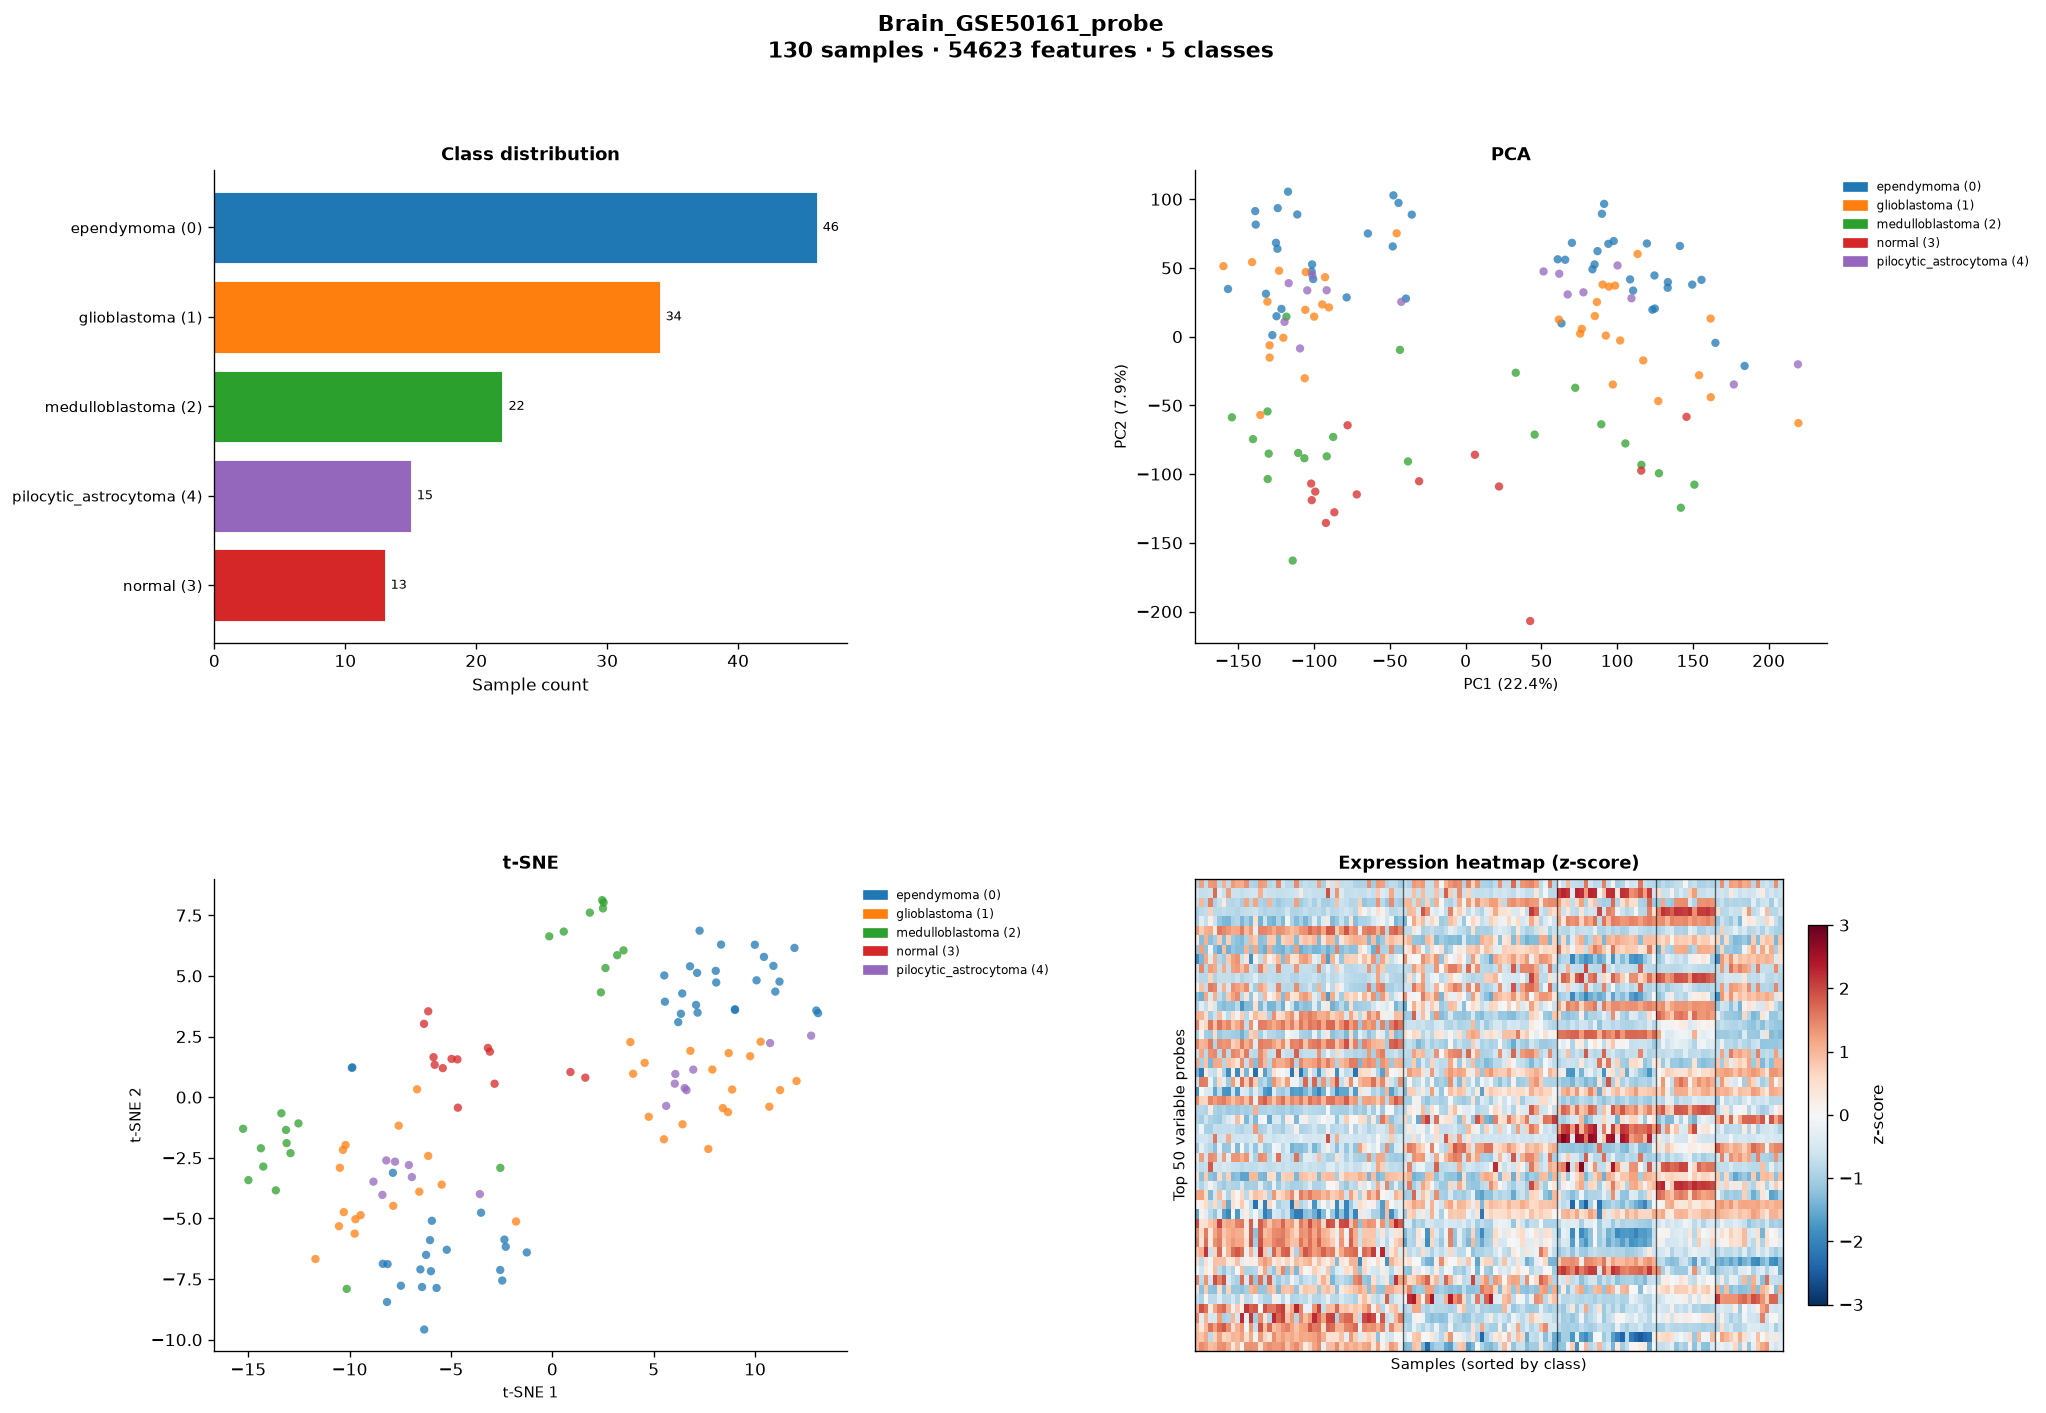


Done. Figures saved under outputs\visualizations


In [9]:
from src.visualize import plot_dataset_overview
import matplotlib.pyplot as plt

for p in all_paths:
    data = loaded[p]
    name = p.stem
    print(f"Plotting {name} ...")

    for show_ids, out_dir, tag in (
        (False, ORIG_DIR,    "original"),
        (True,  LABELED_DIR, "labeled"),
    ):
        fig = plot_dataset_overview(
            data, dataset_name=name,
            figsize=(16, 12), top_n_heatmap=50,
            show_class_ids=show_ids,
        )
        out_path = out_dir / f"{name}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"  [{tag}] -> {out_path.relative_to(REPO_ROOT)}")

        if show_ids:
            plt.show()   # show the labeled version inline (more informative)
        plt.close(fig)

print(f"\nDone. Figures saved under {OUTPUT_DIR.relative_to(REPO_ROOT)}")

## 6. Cross-dataset comparison — class balance

Side-by-side view of class imbalance across all datasets.

Saved -> outputs\visualizations\original\_all_class_distributions.png


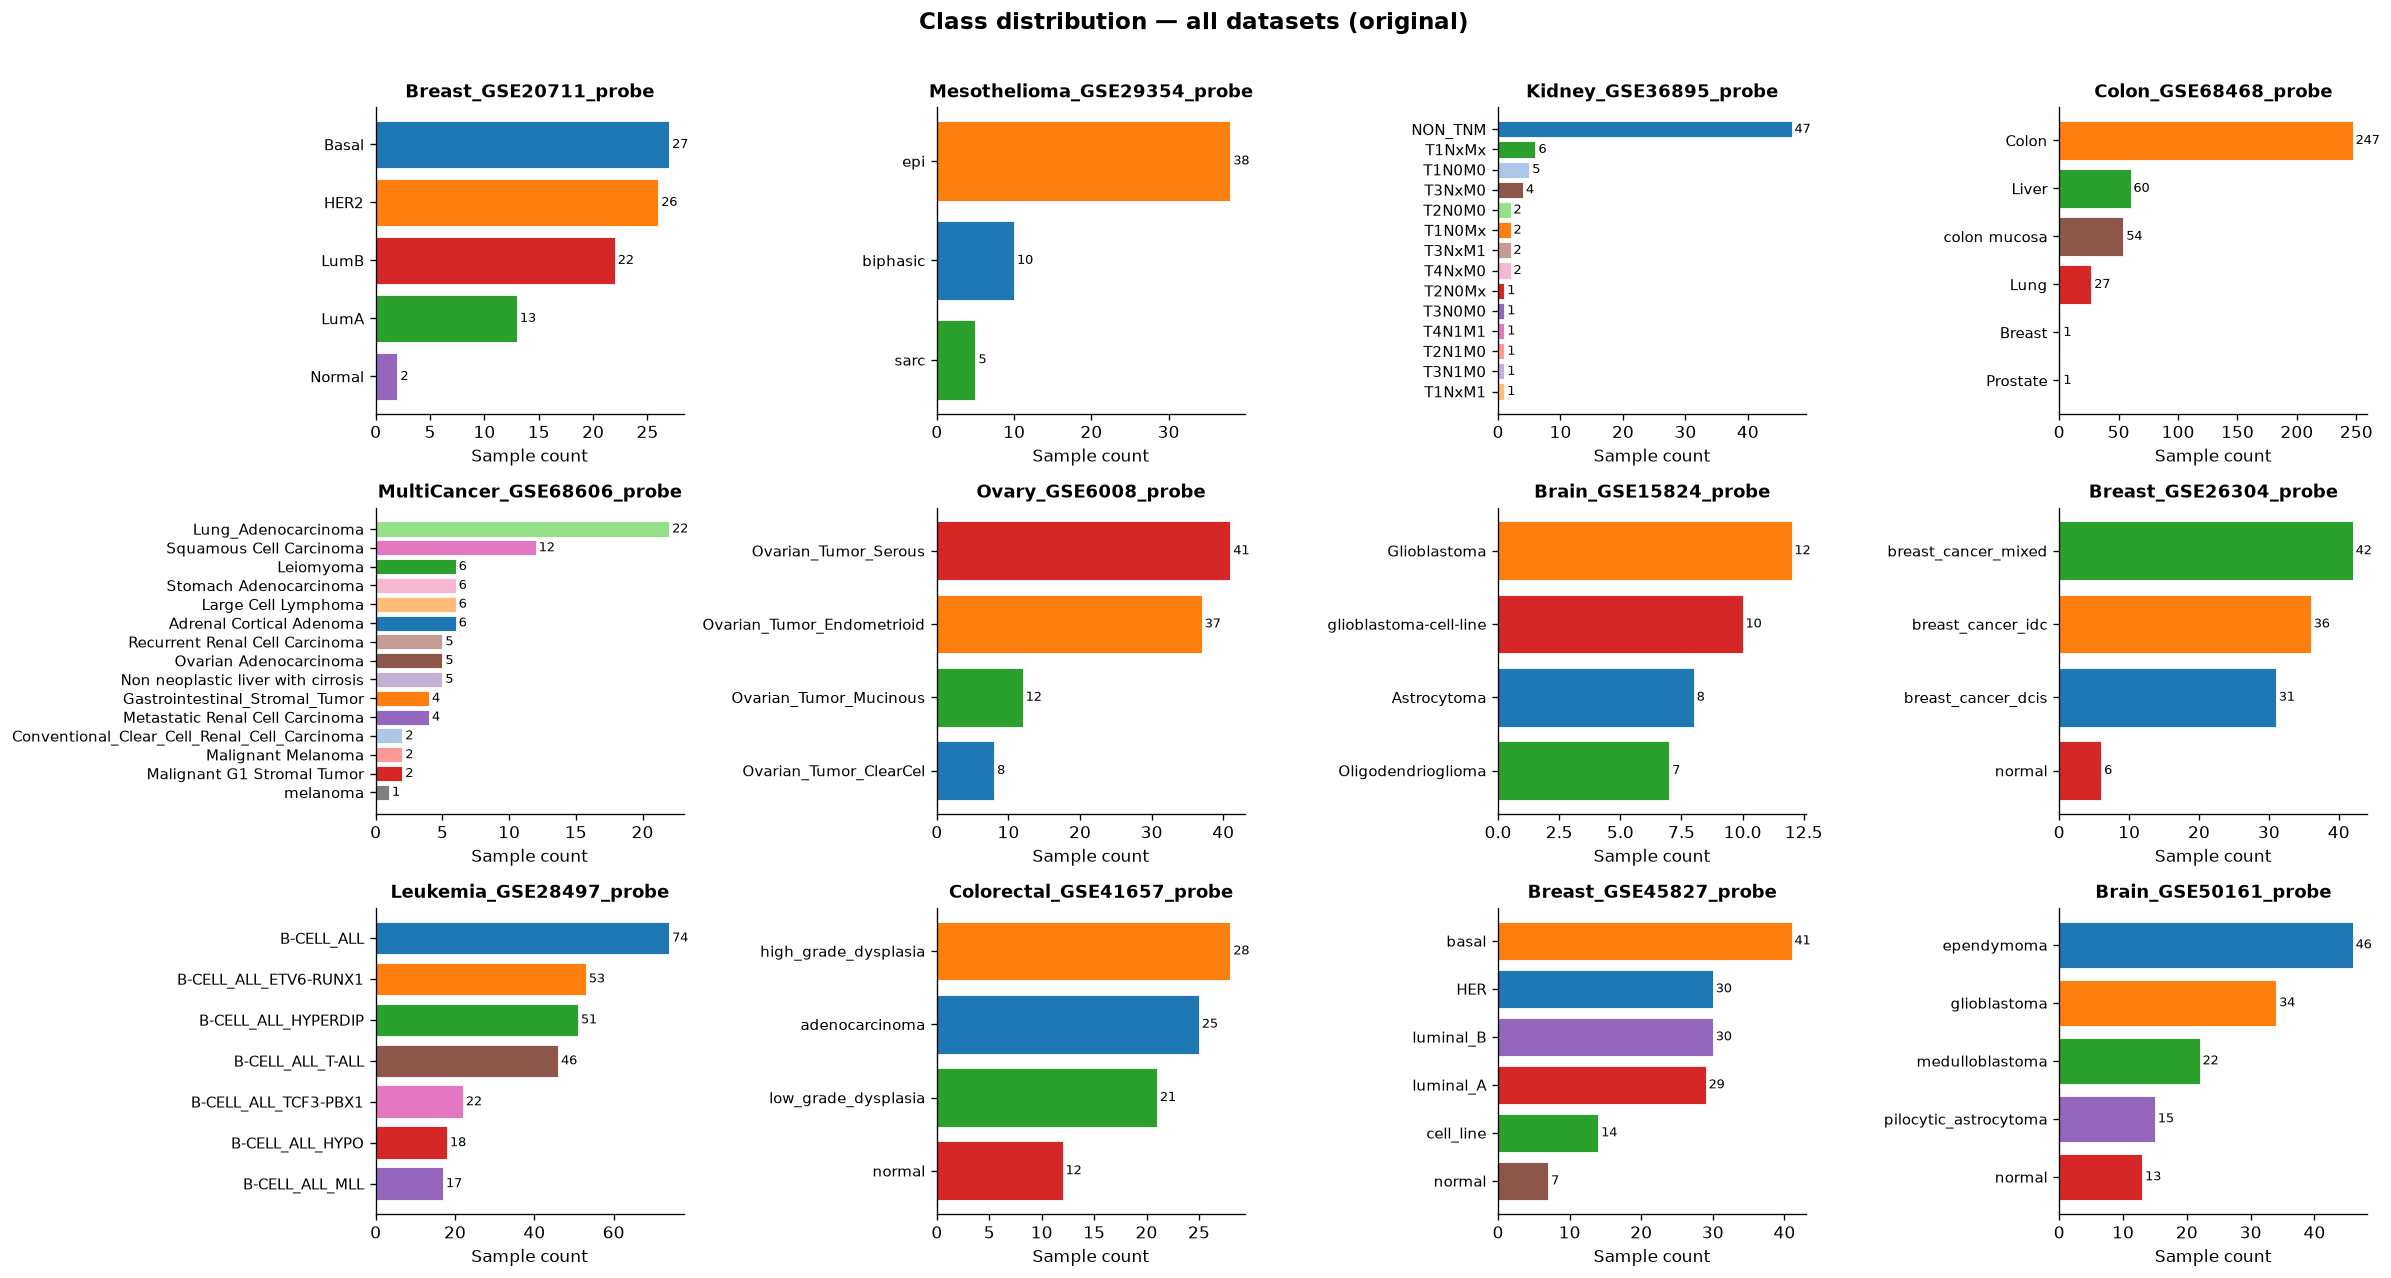

Saved -> outputs\visualizations\labeled\_all_class_distributions.png


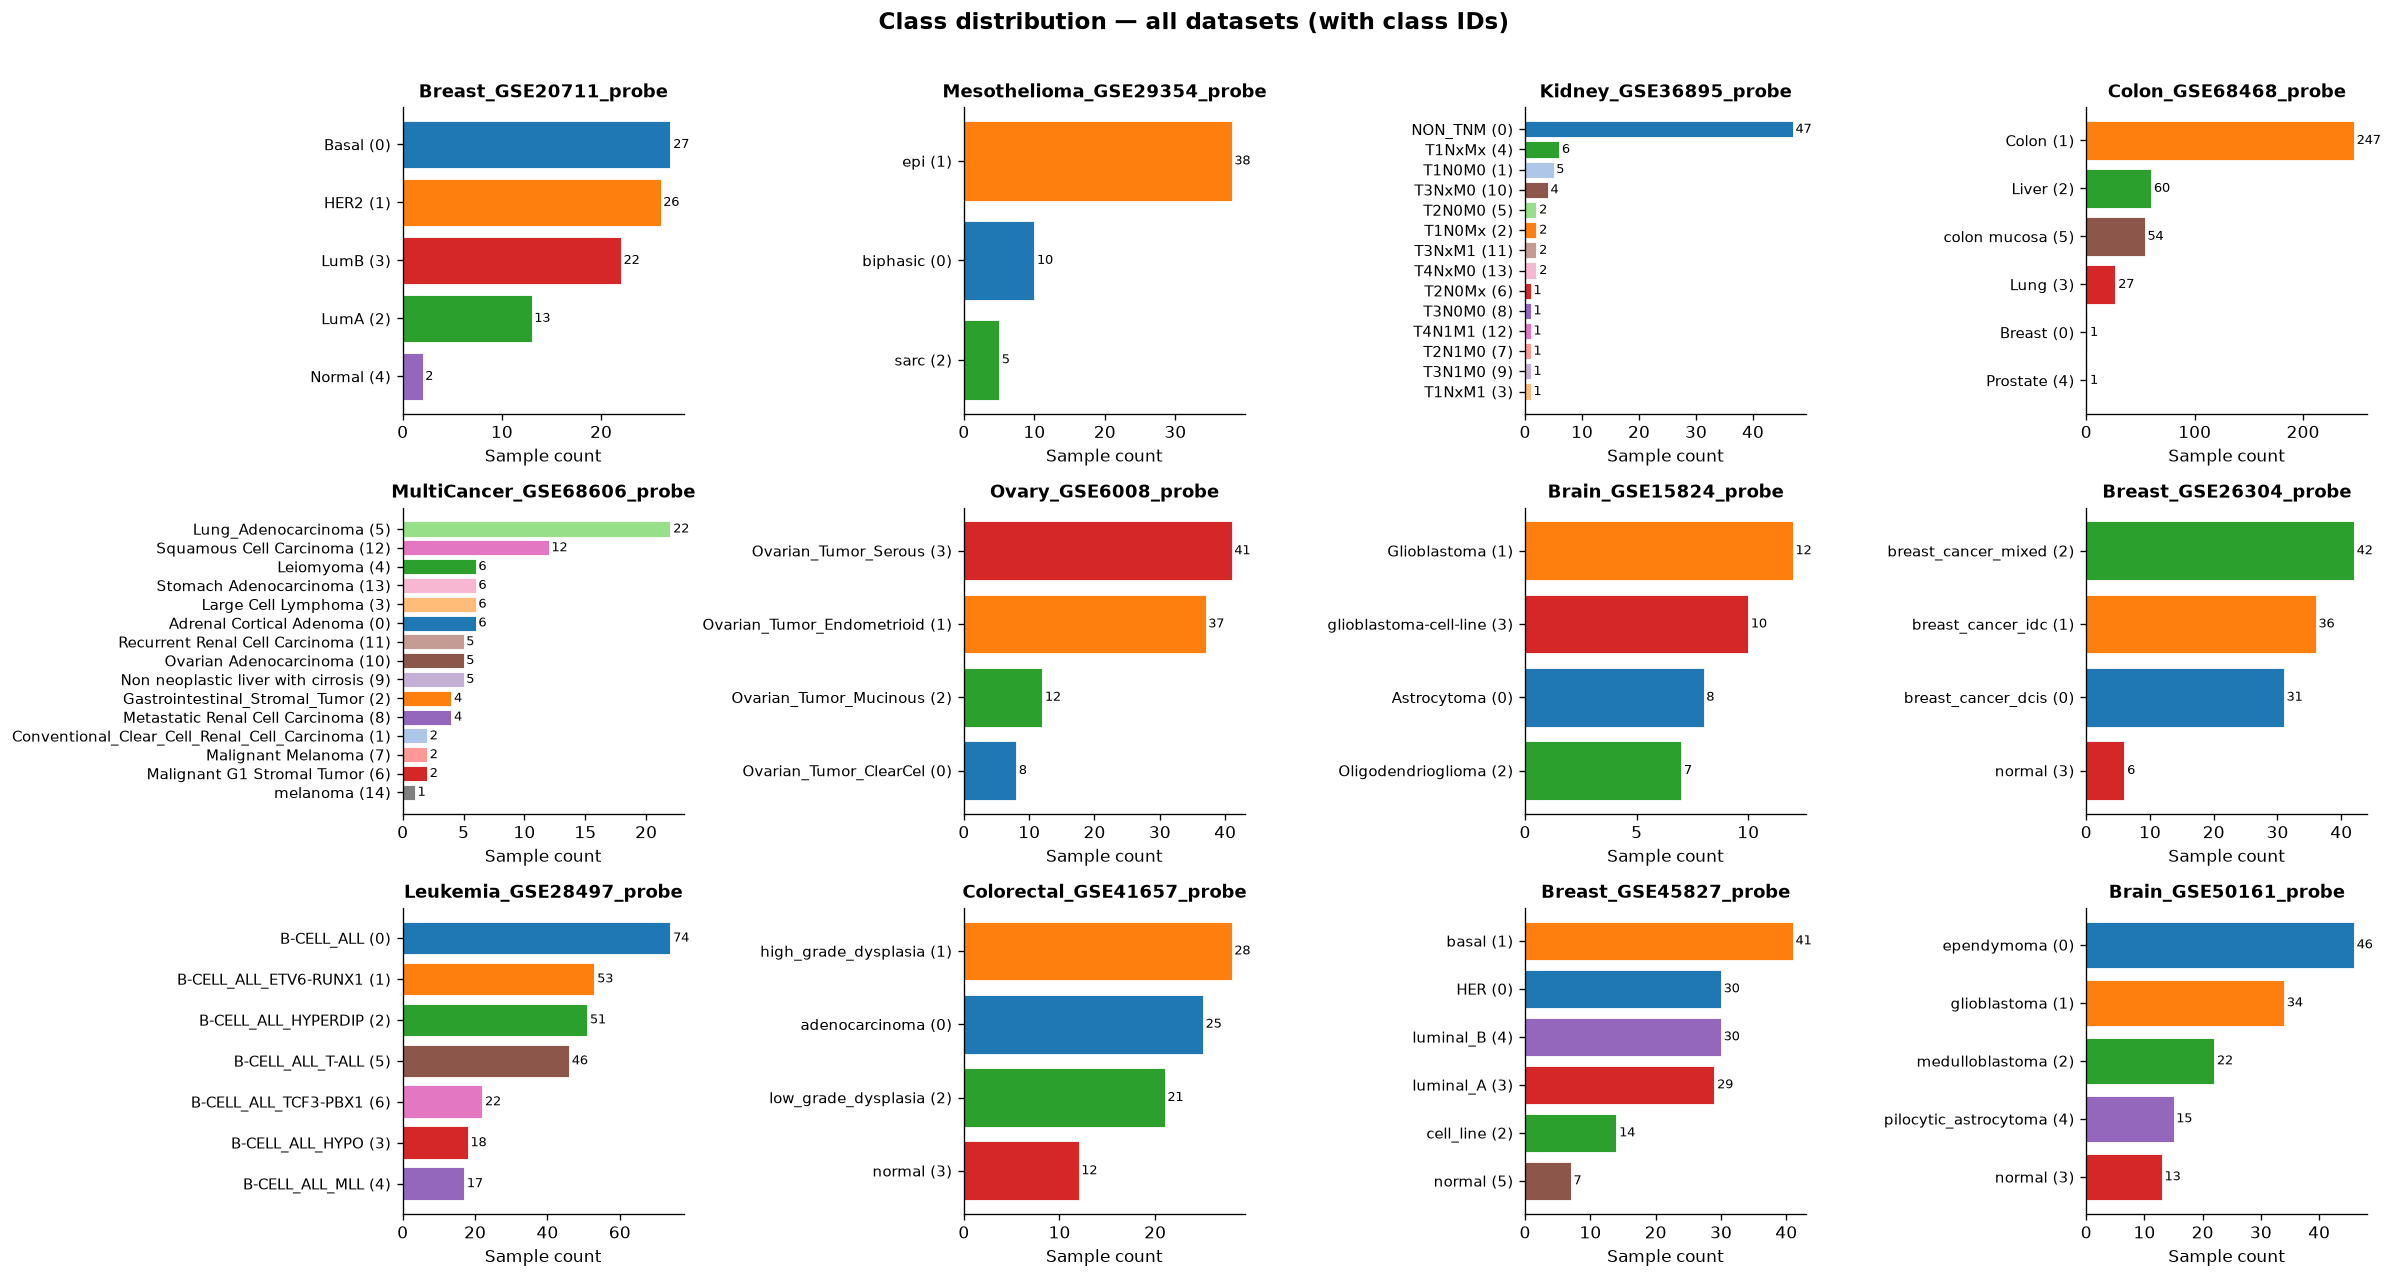

In [10]:
import matplotlib.pyplot as plt
from src.visualize import plot_class_distribution

n_datasets = len(all_paths)
ncols = 4
nrows = (n_datasets + ncols - 1) // ncols

for show_ids, out_dir, fname in (
    (False, ORIG_DIR,    "_all_class_distributions.png"),
    (True,  LABELED_DIR, "_all_class_distributions.png"),
):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes_flat = axes.flatten()

    for i, p in enumerate(all_paths):
        plot_class_distribution(loaded[p], title=p.stem, ax=axes_flat[i],
                                show_class_ids=show_ids)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    label = "with class IDs" if show_ids else "original"
    fig.suptitle(f"Class distribution — all datasets ({label})",
                 fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()

    out_path = out_dir / fname
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path.relative_to(REPO_ROOT)}")
    plt.show()
    plt.close(fig)

## 7. Cross-dataset comparison — PCA

Saved -> outputs\visualizations\original\_all_pca.png


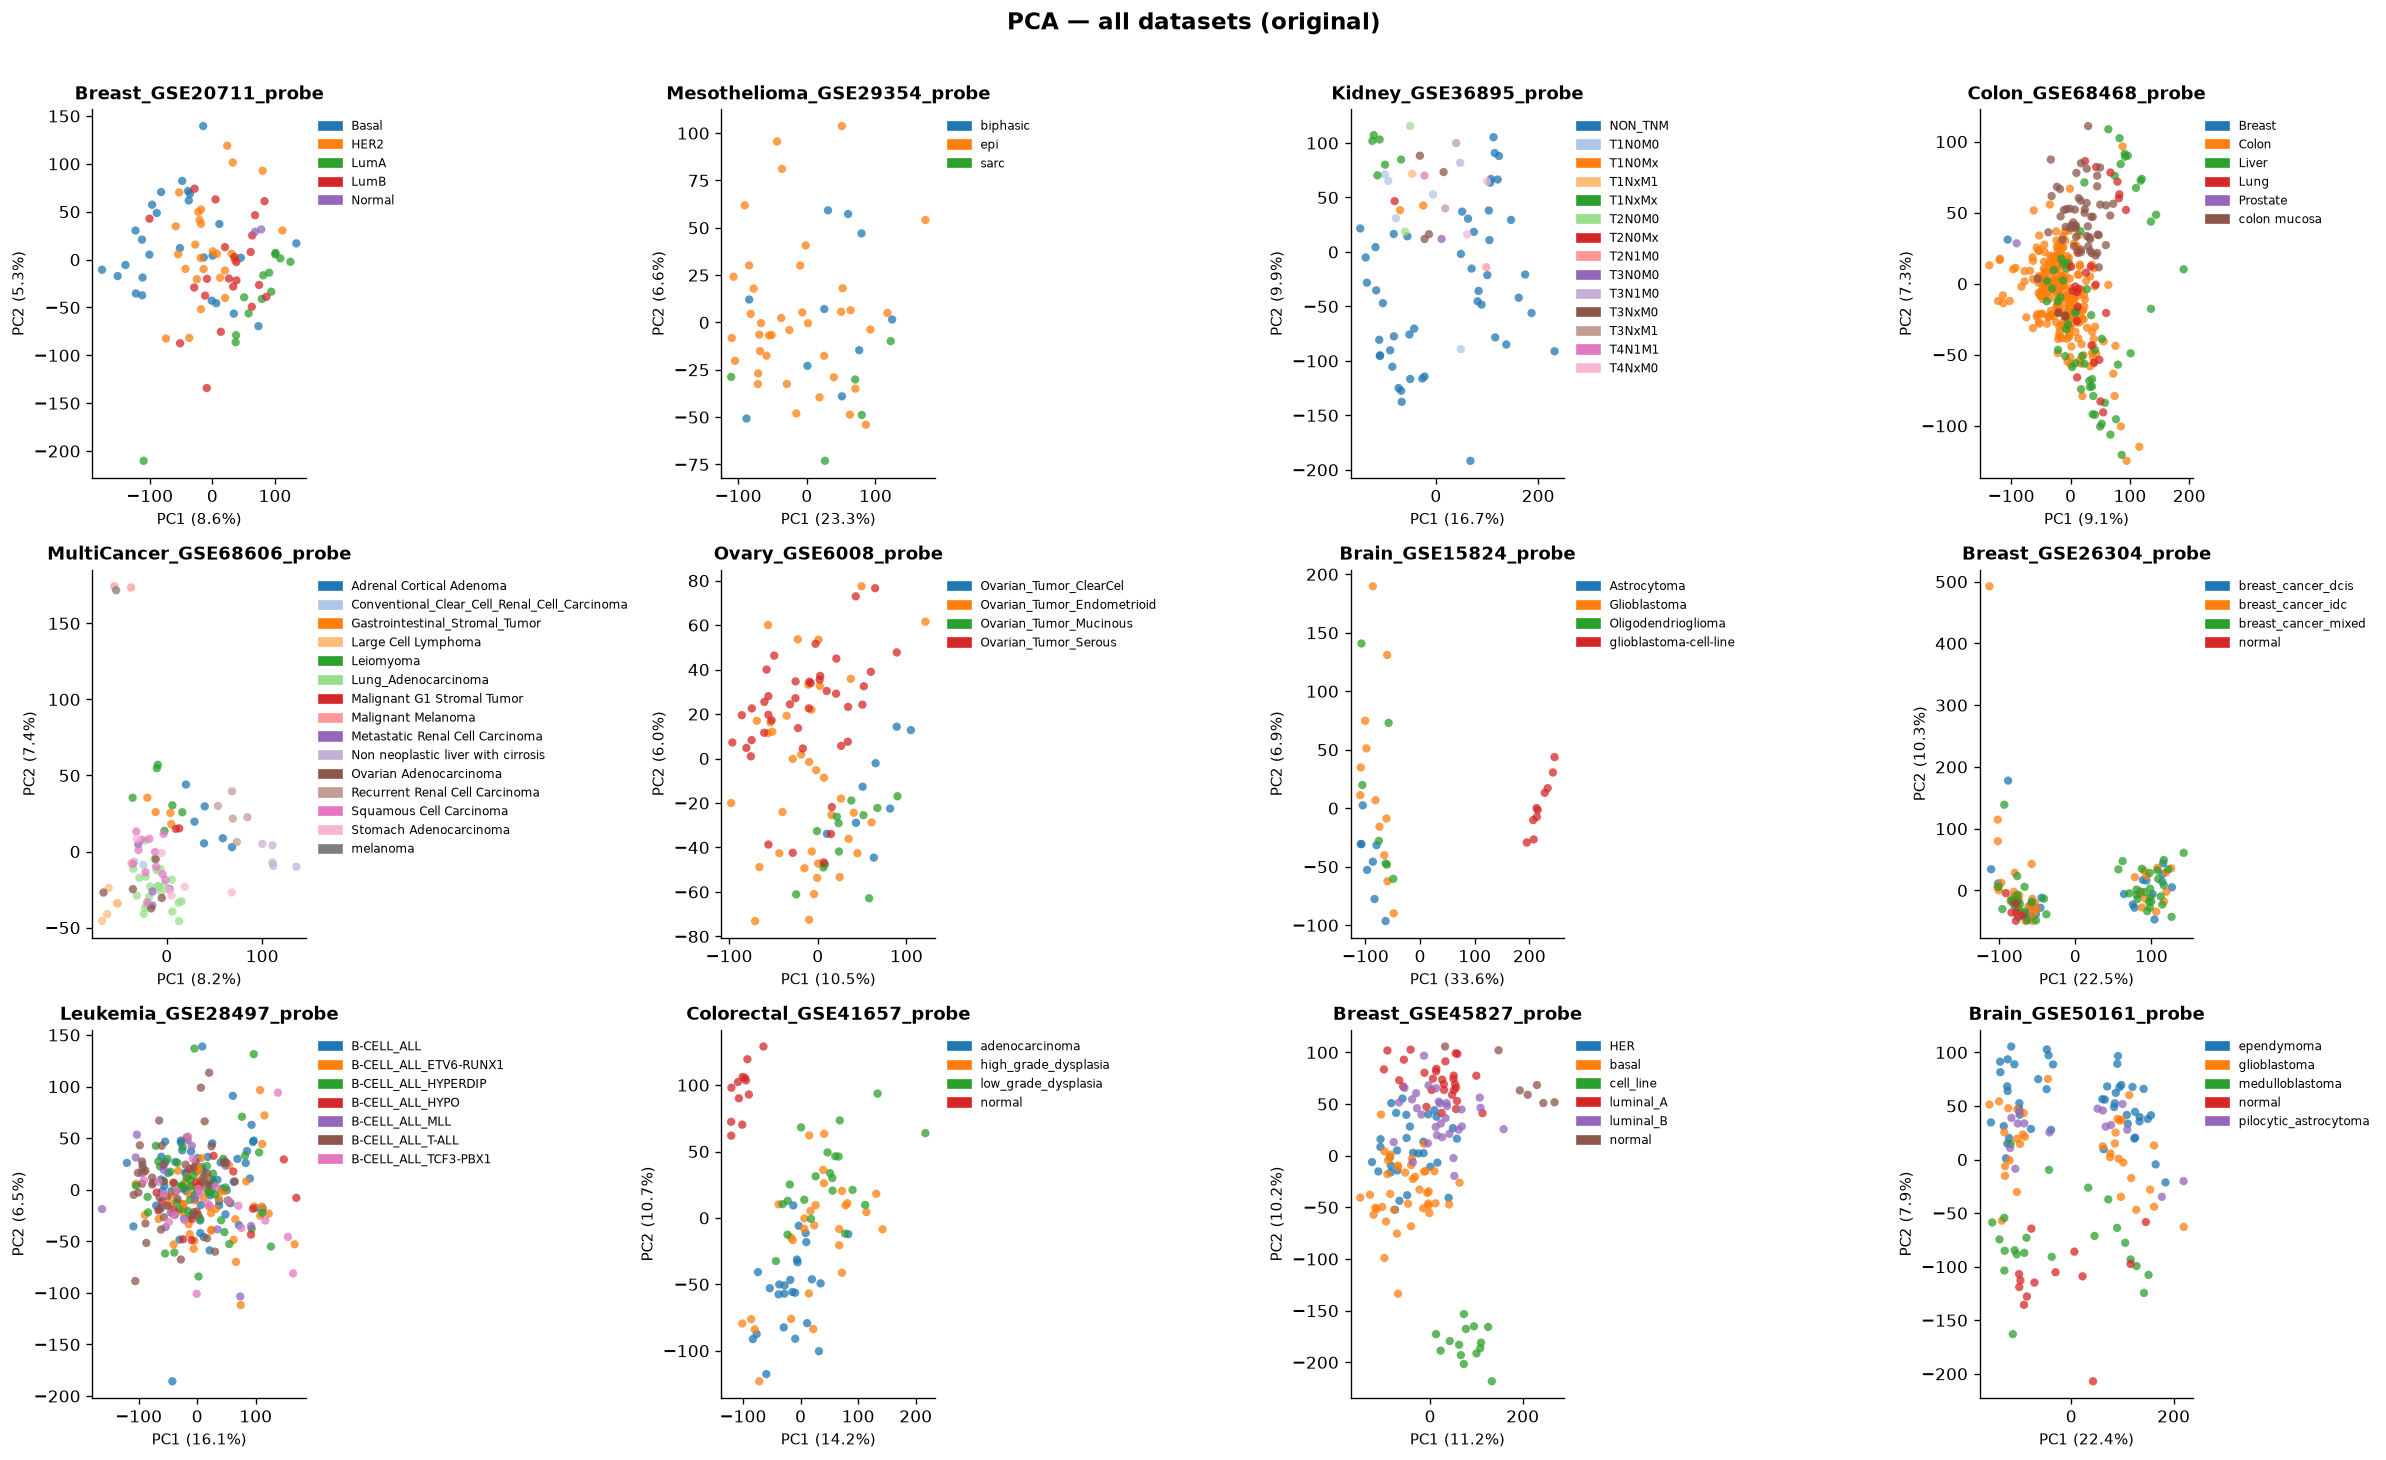

Saved -> outputs\visualizations\labeled\_all_pca.png


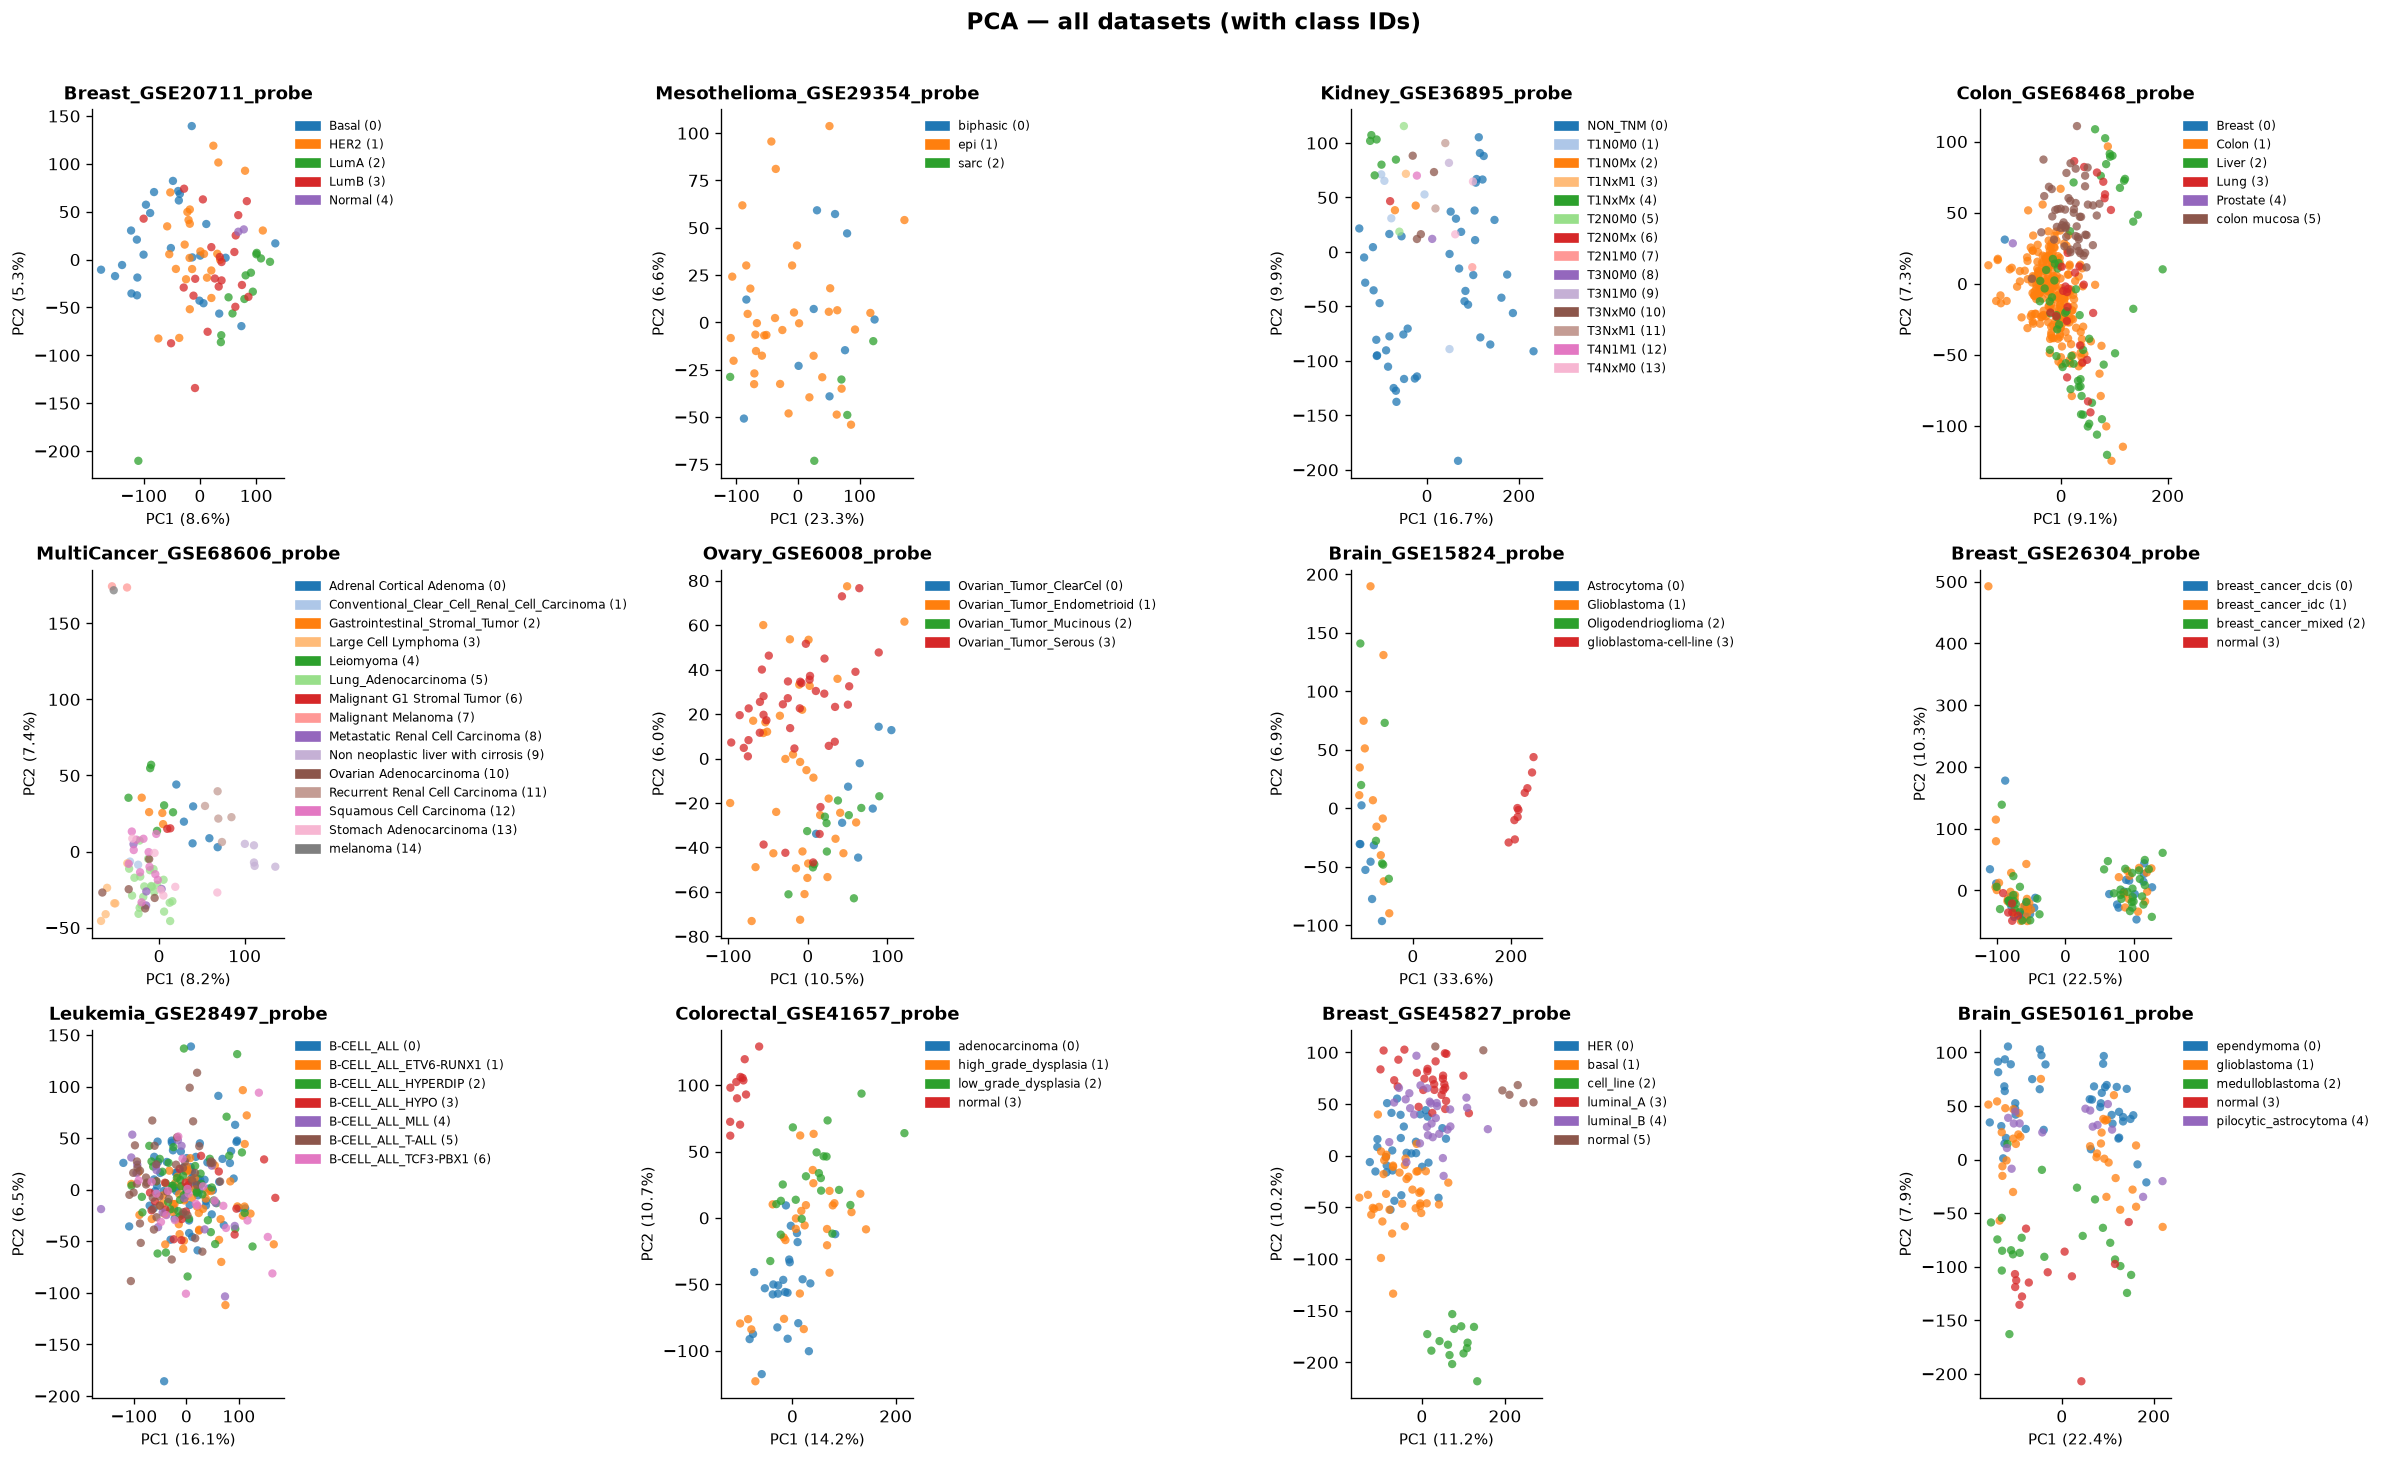

In [11]:
from src.visualize import plot_pca

for show_ids, out_dir, fname in (
    (False, ORIG_DIR,    "_all_pca.png"),
    (True,  LABELED_DIR, "_all_pca.png"),
):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes_flat = axes.flatten()

    for i, p in enumerate(all_paths):
        plot_pca(loaded[p], title=p.stem, ax=axes_flat[i],
                 show_class_ids=show_ids)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    label = "with class IDs" if show_ids else "original"
    fig.suptitle(f"PCA — all datasets ({label})",
                 fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()

    out_path = out_dir / fname
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path.relative_to(REPO_ROOT)}")
    plt.show()
    plt.close(fig)